In [ ]:
from google.colab import drive; drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install yfinance pandas numpy scikit-learn hmmlearn matplotlib seaborn networkx

In [ ]:
from hmmlearn.hmm import GaussianHMM
import math
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import seaborn as sns
import random
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, mean_squared_error, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor
from statsmodels.tsa.stattools import adfuller
import time
import warnings
import yfinance as yf

#1.1. Objetivo: Extraer se˜nales a partir del ruido financiero

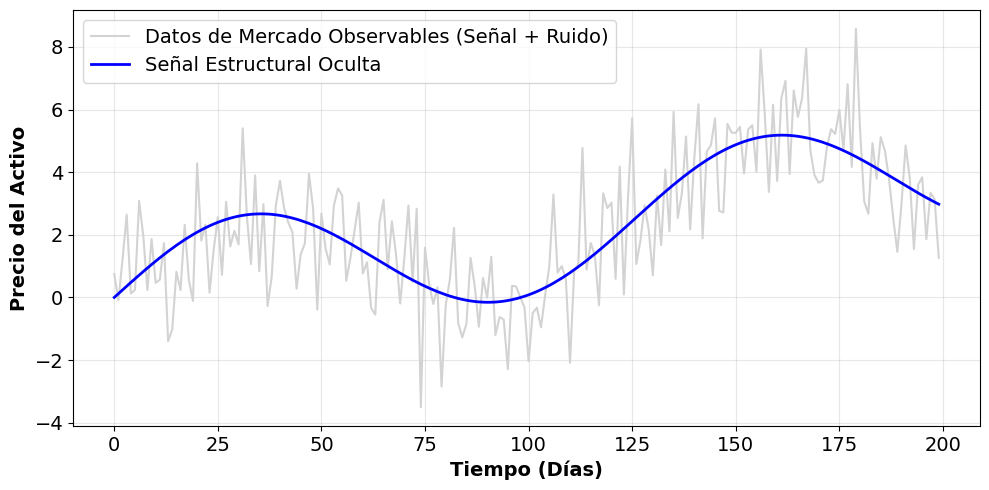

In [ ]:
# Establecer semilla para reproducibilidad
np.random.seed(42)

# 1. Generar la 'Señal Verdadera' (ej. una tendencia de mercado lenta y estructural)
dias = np.arange(200)
senal_verdadera = np.sin(dias / 20) * 2 + (dias / 50)

# 2. Generar el 'Ruido de Mercado' (estocasticidad de alta varianza)
ruido_mercado = np.random.normal(loc=0, scale=1.5, size=200)

# 3. Combinar para crear el 'Precio de Mercado Observable'
precio_observable = senal_verdadera + ruido_mercado

# Graficando el desafío descrito en la Sección 1.1
plt.figure(figsize=(10, 5))
plt.plot(dias, precio_observable, label='Datos de Mercado Observables (Señal + Ruido)', color='lightgray')
plt.plot(dias, senal_verdadera, label='Señal Estructural Oculta', color='blue', linewidth=2)
plt.xlabel('Tiempo (Días)', fontsize=14, fontweight='bold')
plt.ylabel('Precio del Activo', fontsize=14, fontweight='bold')
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#1.2. El Efecto "Promediado"

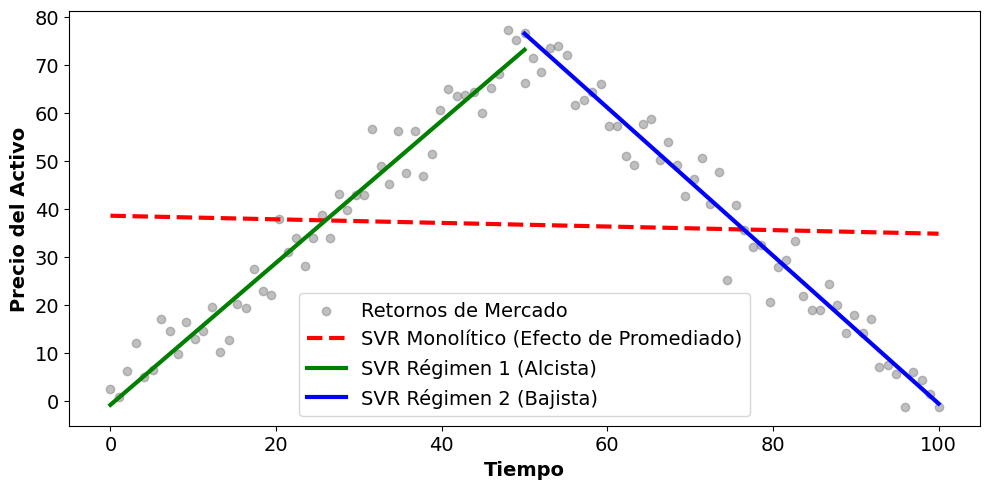

In [ ]:
# 1. Simular un Mercado No Estacionario (Dos Regímenes)
np.random.seed(42)

# Mercado Alcista Fuerte (Regímen 1)
X_alcista = np.linspace(0, 50, 50).reshape(-1, 1)
y_alcista = X_alcista.ravel() * 1.5 + np.random.normal(0, 5, 50)

# Mercado Bajista Fuerte (Régimen 2)
X_bajista = np.linspace(50, 100, 50).reshape(-1, 1)
y_bajista = - (X_bajista.ravel() - 50) * 1.5 + 75 + np.random.normal(0, 5, 50)

X_total = np.vstack((X_alcista, X_bajista))
y_total = np.concatenate((y_alcista, y_bajista))

# 2. Entrenar un SVR Monolítico (Forzándolo a encontrar un óptimo global)
svr_monolitico = SVR(kernel='linear', C=1.0)
svr_monolitico.fit(X_total, y_total)
y_pred_monolitico = svr_monolitico.predict(X_total)

# 3. Entrenar SVRs Específicos por Régimen (Tu Lógica Jerárquica)
svr_experto_alcista = SVR(kernel='linear', C=1.0).fit(X_alcista, y_alcista)
svr_experto_bajista = SVR(kernel='linear', C=1.0).fit(X_bajista, y_bajista)

# Graficando el VERDADERO Efecto de Promediado
plt.figure(figsize=(10, 5))
plt.scatter(X_total, y_total, color='gray', label='Retornos de Mercado', alpha=0.5)

# El fracaso Monolítico: ¡Dibuja una línea plana!
plt.plot(X_total, y_pred_monolitico, color='red', linewidth=3, linestyle='--',
          label='SVR Monolítico (Efecto de Promediado)')

# El éxito Jerárquico: Adaptándose a regímenes locales
plt.plot(X_alcista, svr_experto_alcista.predict(X_alcista), color='green',
         linewidth=3, label='SVR Régimen 1 (Alcista)')
plt.plot(X_bajista, svr_experto_bajista.predict(X_bajista), color='blue',
         linewidth=3, label='SVR Régimen 2 (Bajista)')

plt.xlabel('Tiempo', fontsize=14, fontweight='bold')
plt.ylabel('Precio del Activo', fontsize=14, fontweight='bold')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()


#1.3. No Estacionariedad

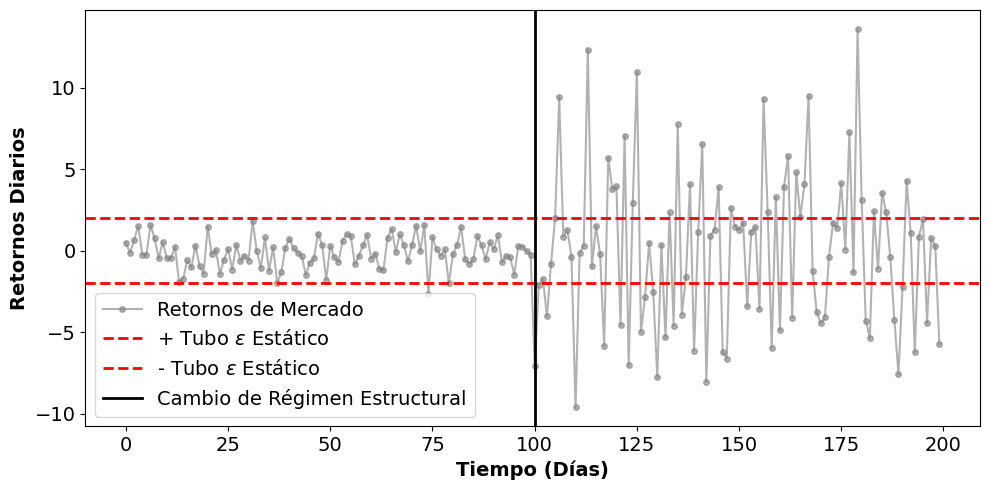

In [ ]:
# 1. Simular Varianza No Estacionaria (Cambio de Régimen de Volatilidad)
np.random.seed(42)
tiempo = np.arange(200)

# Régimen 0: Baja Volatilidad (Mercado Calmo)
mercado_calmo = np.random.normal(0, 1, 100)
# Régimen 1: Alta Volatilidad (Colapso de Mercado / Crisis)
mercado_volatil = np.random.normal(0, 5, 100)

retornos_no_estacionarios = np.concatenate((mercado_calmo, mercado_volatil))

# Tubo épsilon del SVR Monolítico (Tolerancia estática al ruido)
epsilon_estatico = 2.0

plt.figure(figsize=(10, 5))
plt.plot(tiempo, retornos_no_estacionarios, color='gray', label='Retornos de Mercado',
         marker='o', markersize=4, alpha=0.6)

# Graficando el umbral estático del SVR
plt.axhline(y=epsilon_estatico, color='red', linestyle='--', linewidth=2,
            label='+ Tubo $\epsilon$ Estático')
plt.axhline(y=-epsilon_estatico, color='red', linestyle='--', linewidth=2,
            label='- Tubo $\epsilon$ Estático')

# Marcando el cambio estructural
plt.axvline(x=100, color='black', linestyle='-', linewidth=2,
            label='Cambio de Régimen Estructural')

plt.xlabel('Tiempo (Días)', fontsize=14, fontweight='bold')
plt.ylabel('Retornos Diarios', fontsize=14, fontweight='bold')
plt.legend(fontsize=14, loc='lower left')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#1.4. La Maldición de la Dimensionalidad

Precisión solo con la señal: 0.99
Precisión tras agregar ruido: 0.85


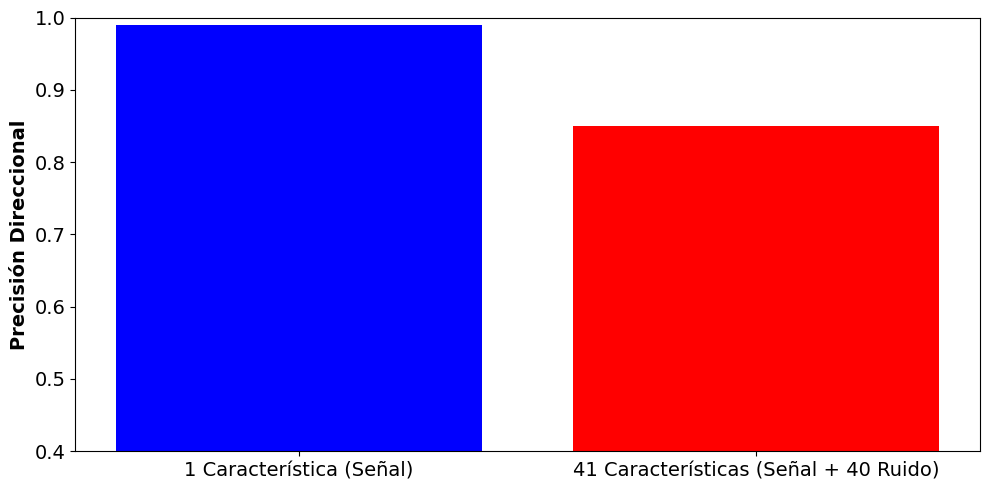

In [ ]:
# 1. Generar una "Señal Clara" (ej. si Momentum > 0, el precio sube)
np.random.seed(42)
n_muestras = 500
momentum = np.random.normal(0, 1, n_muestras)
target = (momentum > 0).astype(int) # 1 si sube, 0 si baja

# 2. Caso A: Baja Dimensionalidad (Solo la señal)
X_limpia = momentum.reshape(-1, 1)

# 3. Caso B: Alta Dimensionalidad (La "Maldición")
# Agregando 40 columnas de ruido aleatorio (ej. "Precipitación Diaria" o números al azar)
caracteristicas_ruido = np.random.normal(0, 1, (n_muestras, 40))
X_ruidosa = np.hstack([X_limpia, caracteristicas_ruido])

# 4. Función de Evaluación
def evaluar_modelo(X, y):
    X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42)

    # Escalar datos (¡SVR/SVC es sensible a la escala!)
    escalador = StandardScaler()
    X_entrenamiento = escalador.fit_transform(X_entrenamiento)
    X_prueba = escalador.transform(X_prueba)

    modelo = SVC(kernel='rbf')
    modelo.fit(X_entrenamiento, y_entrenamiento)
    predicciones = modelo.predict(X_prueba)

    return accuracy_score(y_prueba, predicciones)

precis_baja = evaluar_modelo(X_limpia, target)
precis_alta = evaluar_modelo(X_ruidosa, target)

# 5. Visualizar la "Dilución" de la señal
plt.figure(figsize=(10, 5))
plt.bar(['1 Característica (Señal)', '41 Características (Señal + 40 Ruido)'],
        [precis_baja, precis_alta], color=['blue', 'red'])
plt.ylabel('Precisión Direccional', fontsize=14,fontweight='bold')
plt.ylim(0.4, 1.0)

print(f"Precisión solo con la señal: {precis_baja:.2f}")
print(f"Precisión tras agregar ruido: {precis_alta:.2f}")

plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()



#2.1. Microestructura (LOB) Agregando Datos Diarios y Ingeniería de Características que Alimentan a los modelos.


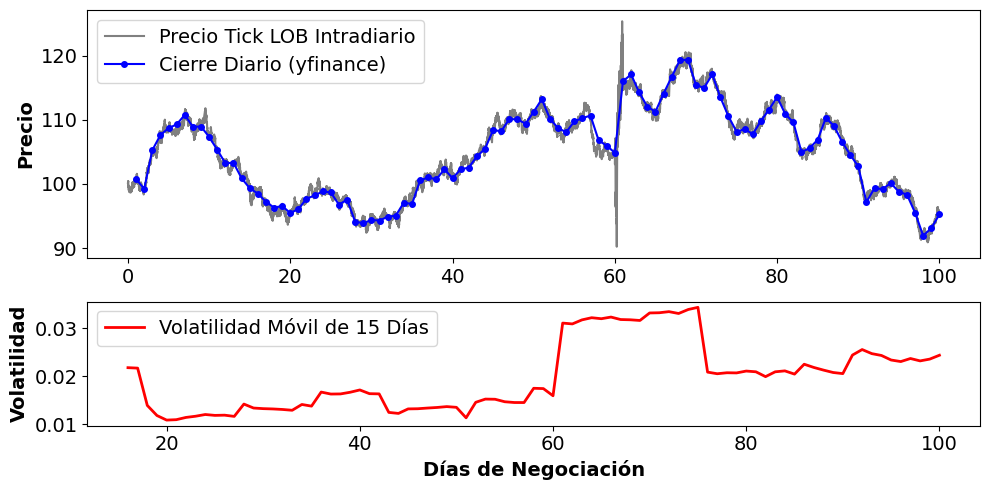

In [ ]:
# 1. Simular Datos de Alta Frecuencia del LOB (Limit Order Book)
np.random.seed(42)
dias = 100 # Incrementado a 100 días para asegurar datos suficientes para la ventana de 15 días
ticks_intradiarios = 390 # Minutos en un día de negociación estándar
total_ticks = dias * ticks_intradiarios

# Simular el rebote bid-ask del LOB y el ruido
retornos_lob = np.random.normal(0, 0.001, total_ticks)
# Inyectar un choque de liquidez severo alrededor del día 60
retornos_lob[60*ticks_intradiarios : 61*ticks_intradiarios] = np.random.normal(0, 0.01, ticks_intradiarios)

precios_tick = 100 * np.exp(np.cumsum(retornos_lob))

# 2. Agregar a Datos Diarios (Simulando yfinance)
# Extraer solo el último tick de cada bloque de 390 minutos para el "Cierre Diario"
cierres_diarios = precios_tick[ticks_intradiarios-1::ticks_intradiarios]
df_diario = pd.DataFrame({'Precio': cierres_diarios})

# Calcular las características de ingeniería (feature engineering)
df_diario['Retorno_Log'] = np.log(df_diario['Precio'] / df_diario['Precio'].shift(1))
df_diario['Vol_Movil_15'] = df_diario['Retorno_Log'].rolling(window=15).std()

# 3. Visualización
fig, axes = plt.subplots(2, 1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})

# Gráfico 1: Intradiario vs. Diario
axes[0].plot(np.linspace(0, dias, total_ticks), precios_tick, color='gray', label='Precio Tick LOB Intradiario')
axes[0].plot(np.arange(1, dias+1), cierres_diarios, color='blue', marker='o', markersize=4, label='Cierre Diario (yfinance)')
axes[0].set_ylabel('Precio', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=14)
axes[0].tick_params(axis='both', which='major', labelsize=14)

# Gráfico 2: La característica de volatilidad derivada
axes[1].plot(np.arange(1, dias+1), df_diario['Vol_Movil_15'], color='red', linewidth=2, label='Volatilidad Móvil de 15 Días')
axes[1].set_xlabel('Días de Negociación', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volatilidad', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=14)

axes[1].tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#2.2. Regularización de Árboles de Decisiones: Restricciones Topologicas vs Sobreajuste


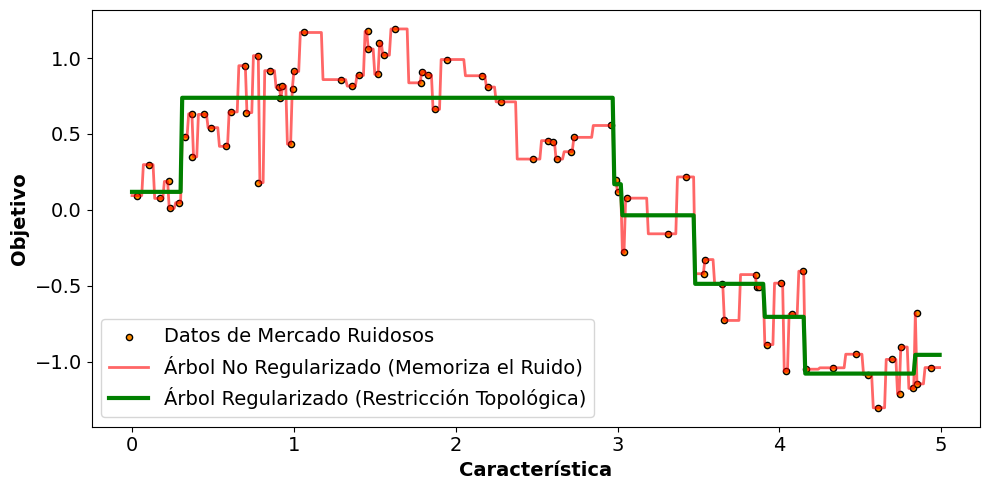

In [ ]:
# 1. Simular una tendencia de mercado ruidosa
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

# 2. Entrenar un Árbol No Regularizado (Profundidad infinita = Sobreajuste)
tree_unregularized = DecisionTreeRegressor(max_depth=None)
tree_unregularized.fit(X, y)

# 3. Entrenar un Árbol Topológicamente Regularizado (max_depth=3)
tree_regularized = DecisionTreeRegressor(max_depth=3)
tree_regularized.fit(X, y)

# Predecir
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

# Visualizar
plt.figure(figsize=(10, 5))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Datos de Mercado Ruidosos")
plt.plot(X_test, tree_unregularized.predict(X_test), color="red", label="Árbol No Regularizado (Memoriza el Ruido)", linewidth=2, alpha=0.6)
plt.plot(X_test, tree_regularized.predict(X_test), color="green", label="Árbol Regularizado (Restricción Topológica)", linewidth=3)

plt.xlabel("Característica", fontsize=14, fontweight='bold')
plt.ylabel("Objetivo", fontsize=14, fontweight='bold')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#2.3. ¿Por qué el Ensamble Funciona? Varianza de un Árbol vs. Suavizamiento del Random Forest


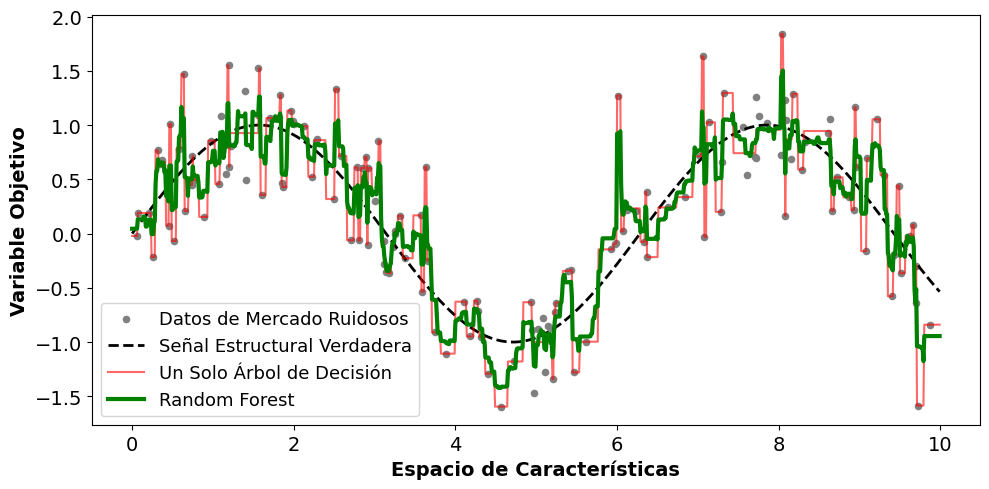

In [ ]:
# 1. Simular una tendencia estructural ruidosa
np.random.seed(42)
X = np.sort(10 * np.random.rand(150, 1), axis=0)
# Señal verdadera (onda senoidal) + Fuerte ruido de mercado
y = np.sin(X).ravel() + np.random.normal(0, 0.4, X.shape[0])

# 2. Entrenar un Solo Árbol de Decisión (Propenso a alta varianza/sobreajuste)
tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X, y)

# 3. Entrenar un Random Forest (Ensamble de 100 árboles que reduce la varianza)
forest = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
forest.fit(X, y)

# 4. Predecir
X_test = np.arange(0.0, 10.0, 0.01)[:, np.newaxis]
y_tree = tree.predict(X_test)
y_forest = forest.predict(X_test)

# 5. Visualización para tu Presentación de Defensa
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color="gray", label="Datos de Mercado Ruidosos", s=20)
plt.plot(X_test, np.sin(X_test), color="black", label="Señal Estructural Verdadera", linewidth=2, linestyle="--")

# El fracaso de un solo árbol
plt.plot(X_test, y_tree, color="red", label="Un Solo Árbol de Decisión", linewidth=1.5, alpha=0.6)
# El éxito del ensamble
plt.plot(X_test, y_forest, color="green", label="Random Forest", linewidth=3)
plt.xlabel("Espacio de Características", fontsize=14, fontweight='bold')
plt.ylabel("Variable Objetivo", fontsize=14, fontweight='bold')
plt.legend(fontsize=13, loc='lower left')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#2.4 SVR: Ajustando Magnitudes Continuas (Izquierda) & SVC: Separando Clases Direccionales



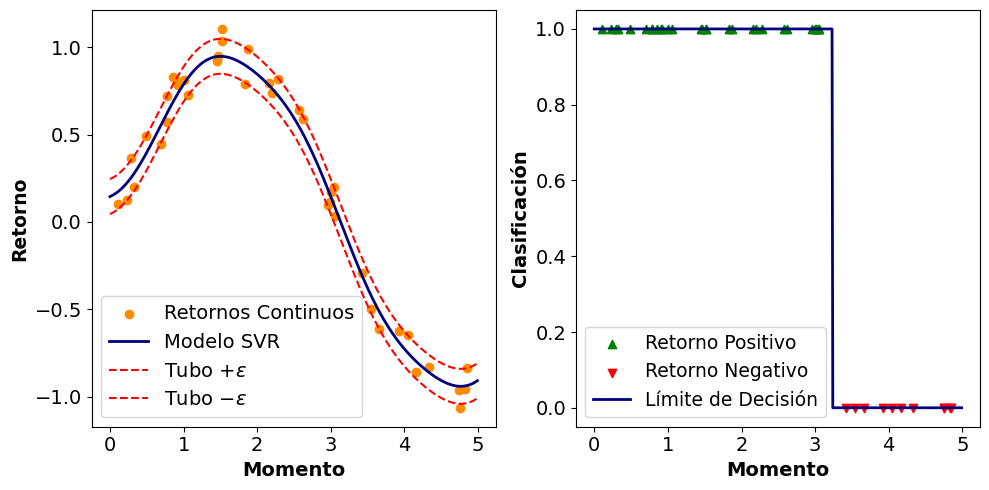

In [ ]:
# 1. Simular un espacio de características 2D simple (ej. Momento vs. Volatilidad)
np.random.seed(42)
X = np.sort(5 * np.random.rand(40, 1), axis=0)

# Objetivo Continuo (Para SVR)
y_continuous = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# Objetivo Binario (Para SVC: ¿El retorno es positivo o negativo?)
y_binary = np.where(y_continuous > 0, 1, 0)

# 2. Entrenar Modelos
# SVR: Intenta ajustar los puntos DENTRO del tubo épsilon
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X, y_continuous)

# SVC: Intenta separar los puntos con un MARGEN
svc = SVC(kernel='rbf', C=100)
svc.fit(X, y_binary)

# 3. Visualización
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Graficar SVR
axes[0].scatter(X, y_continuous, color='darkorange', label='Retornos Continuos')
axes[0].plot(X_test, svr.predict(X_test), color='navy', lw=2, label='Modelo SVR')
# Nota: Usamos la 'r' antes del string para que Matplotlib interprete correctamente el símbolo de LaTeX
axes[0].plot(X_test, svr.predict(X_test) + svr.epsilon, color='red', linestyle='--', label=r'Tubo $+\epsilon$')
axes[0].plot(X_test, svr.predict(X_test) - svr.epsilon, color='red', linestyle='--', label=r'Tubo $-\epsilon$')
axes[0].legend(fontsize=14)
axes[0].set_ylabel('Retorno', fontsize=13.5, fontweight='bold')
axes[0].set_xlabel('Momento', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', which='major', labelsize=14)

# Graficar SVC
axes[1].scatter(X[y_binary == 1], np.ones(sum(y_binary == 1)), color='green', label='Retorno Positivo', marker='^')
axes[1].scatter(X[y_binary == 0], np.zeros(sum(y_binary == 0)), color='red', label='Retorno Negativo', marker='v')
axes[1].plot(X_test, svc.predict(X_test), color='navy', lw=2, label='Límite de Decisión')
axes[1].legend(fontsize=13.5, loc='lower left')
axes[1].set_ylabel('Clasificación', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Momento', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', which='major', labelsize=14)


plt.tight_layout()
plt.show()

#2.5. Eficiencia Computacional

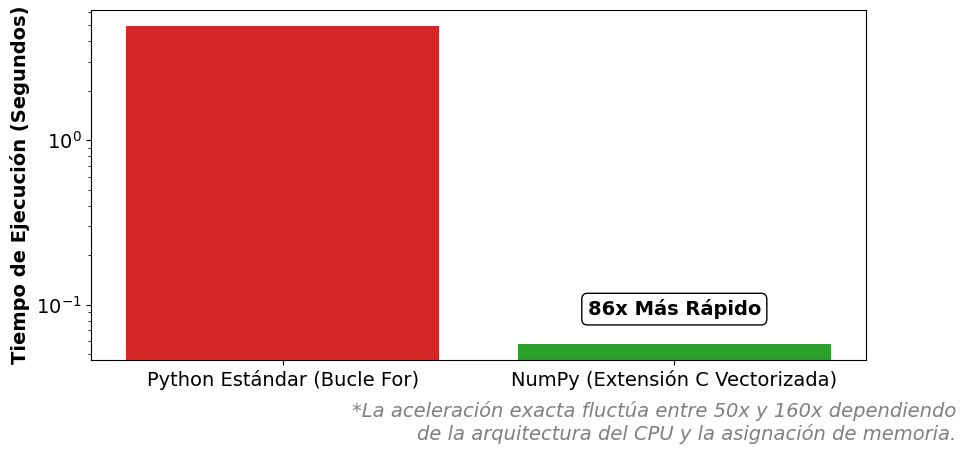

In [ ]:
# 1. Simular un conjunto de datos financieros a gran escala (10 millones de ticks)
np.random.seed(42)
financial_data = np.random.normal(0.0005, 0.01, 10_000_000)

# 2. Evaluación de rendimiento (Benchmark) con Bucle For ingenuo
start_time = time.time()
cumulative_returns_loop = []
current_sum = 0
for return_val in financial_data:
    current_sum += return_val
    cumulative_returns_loop.append(current_sum)
loop_time = time.time() - start_time

# 3. Evaluación de rendimiento con Vectorización de NumPy
start_time = time.time()
cumulative_returns_vectorized = np.cumsum(financial_data)
numpy_time = time.time() - start_time

speedup = loop_time / numpy_time

# 4. Generar el gráfico para la Tesis
methods = ['Python Estándar (Bucle For)', 'NumPy (Extensión C Vectorizada)']
times = [loop_time, numpy_time]

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, times, color=['#d62728', '#2ca02c'])

# Añadir etiquetas y formato
plt.ylabel('Tiempo de Ejecución (Segundos)', fontsize=14, fontweight='bold')
plt.yscale('log') # La escala logarítmica resalta la diferencia masiva

# Añadir el multiplicador de velocidad como texto
plt.text(1, numpy_time * 1.5, f'{speedup:.0f}x Más Rápido', ha='center',
         fontsize=14, fontweight='bold', color='black',
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

plt.tick_params(axis='both', which='major', labelsize=14)

# Agregamos una nota elegante en la esquina inferior para explicar el asterisco
plt.figtext(0.99, 0.02, '*La aceleración exacta fluctúa entre 50x y 160x dependiendo\nde la arquitectura del CPU y la asignación de memoria.',
            horizontalalignment='right', fontsize=14, style='italic', color='gray')

# Aumentamos un poco el margen inferior para que quepa la nota sin cortarse
plt.subplots_adjust(bottom=0.18)
plt.show()

#2.6, 2.7 & 2.8.

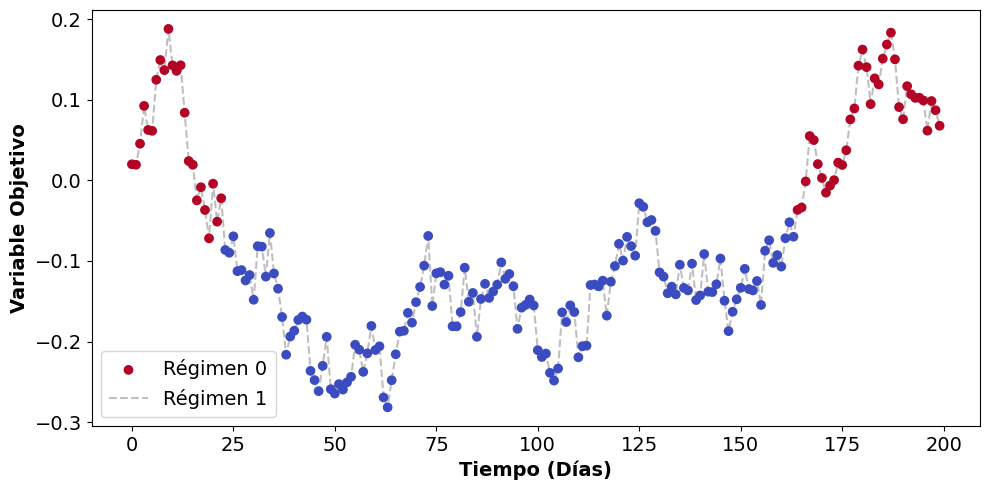

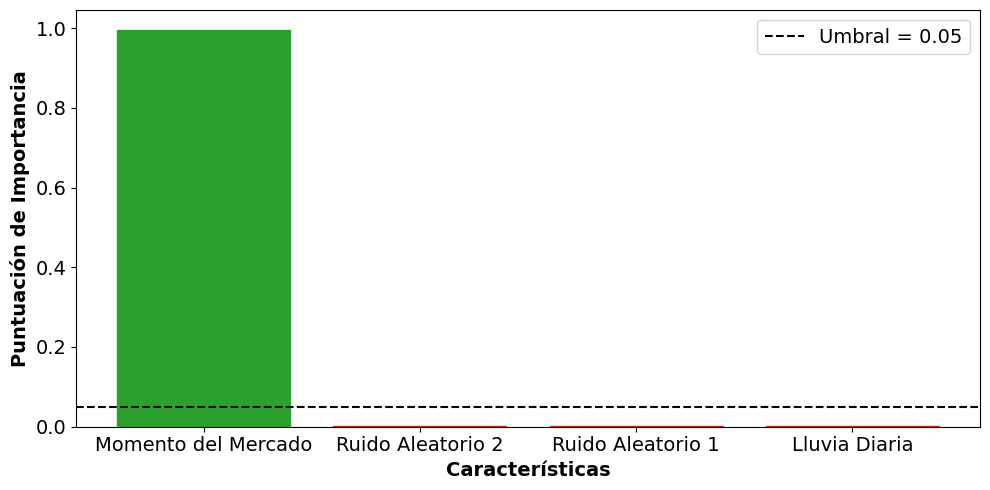

Características Importantes: ['Momento del Mercado']


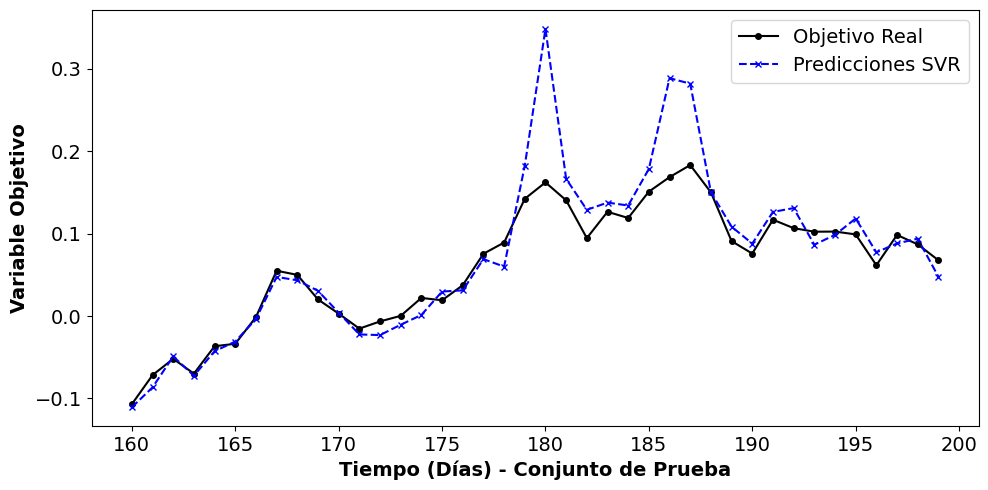

In [ ]:
# 0. Generación de conjunto de datos sintéticos (n=200)
np.random.seed(42)
n = 200

# Señal: Momento del Mercado
market_momentum = np.cumsum(np.random.normal(0.001, 0.02, n))
# Variable Objetivo (Retornos/Precio)
y = market_momentum * 1.5 + np.random.normal(0, 0.01, n)
y = pd.Series(y)

# Variables de Ruido
daily_rainfall = np.random.normal(5, 2, n)
noise_1 = np.random.normal(0, 1, n)
noise_2 = np.random.uniform(-1, 1, n)
X = pd.DataFrame({
    'Momento del Mercado': market_momentum,
    'Lluvia Diaria': daily_rainfall,
    'Ruido Aleatorio 1': noise_1,
    'Ruido Aleatorio 2': noise_2
})

# PASO 1. Identificación de regímenes (GHMM)
hmm_data = y.values.reshape(-1, 1)
model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model_hmm.fit(hmm_data)
regimes_pred = model_hmm.predict(hmm_data)
plt.figure(figsize=(10, 5))
scatter = plt.scatter(range(n), y, c=regimes_pred, cmap='coolwarm', zorder=5)
plt.plot(y, color='gray', alpha=0.5, linestyle='--')
plt.xlabel('Tiempo (Días)', fontsize=14, fontweight='bold')
plt.ylabel('Variable Objetivo', fontsize=14, fontweight='bold')
plt.legend(*scatter.legend_elements(), labels=["Régimen 0", "Régimen 1"],fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# PASO 2. Eliminación de Ruido / IMPORTANCIA DE CARACTERÍSTICAS (RANDOM FOREST)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 5))
bars = plt.bar(range(X.shape[1]), importances[indices], align="center")
# Colorear variables según el umbral de 0.05
for i, val in enumerate(importances[indices]):
    bars[i].set_color('#2ca02c' if val > 0.05 else '#d62728')
plt.xticks(range(X.shape[1]), features[indices], rotation=0)
plt.axhline(y=0.05, color='black', linestyle='--', label='Umbral = 0.05')
plt.ylabel('Puntuación de Importancia', fontsize=14, fontweight='bold')
plt.xlabel('Características', fontsize=14, fontweight='bold')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# Descartar variables de ruido
important_features = features[importances > 0.05]
print("Características Importantes:", list(important_features))

# PASO 3. Pronóstico (REGRESIÓN DE VECTORES DE SOPORTE)
X_filtered = X[important_features]
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42, shuffle=False)
svr = SVR(kernel='rbf', C=1e3, epsilon=0.01)
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)

plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test.values, label='Objetivo Real', color='black', marker='o', markersize=4)
plt.plot(y_test.index, y_pred, label='Predicciones SVR', color='blue', linestyle='--', marker='x', markersize=4)
plt.xlabel('Tiempo (Días) - Conjunto de Prueba', fontsize=14, fontweight='bold')
plt.ylabel('Variable Objetivo', fontsize=14, fontweight='bold')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

#3.0. Prueba ADF

In [ ]:
def probar_estacionariedad_en_universo():
    # El universo exacto de múltiples activos de la Tabla 3.9 de tu Tesis
    tickers = ["SPY", "QQQ", "IWM", "EEM", "GLD", "TLT", "XLE", "EWW", "VXX"]
    resultados = []

    print("Obteniendo datos y ejecutando pruebas de Dickey-Fuller Aumentada...\n")

    for ticker in tickers:
        try:
            # Descargar la misma línea de tiempo 2000-2025 utilizada en tu tesis
            datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)

            # Manejar columnas MultiIndex de yfinance si están presentes
            if isinstance(datos.columns, pd.MultiIndex):
                serie_precio = datos['Adj Close'].iloc[:, 0] if 'Adj Close' in datos.columns else datos['Close'].iloc[:, 0]
            else:
                serie_precio = datos['Adj Close'] if 'Adj Close' in datos.columns else datos['Close']

            # Paso 1: Calcular Retornos Logarítmicos continuamente compuestos
            retornos_log = np.log(serie_precio / serie_precio.shift(1)).dropna()

            # Paso 2: Realizar Prueba ADF
            resultado_adf = adfuller(retornos_log)
            valor_p = resultado_adf[1]
            estadistico_adf = resultado_adf[0]

            # Paso 3: Añadir resultados
            resultados.append({
                "Ticker": ticker,
                "Estadístico ADF": round(estadistico_adf, 4),
                "p-value": f"{valor_p:.4e}",
                "¿Es Estacionario (p < 0.05)?": "Sí" if valor_p < 0.05 else "No"
            })

        except Exception as e:
            resultados.append({
                "Ticker": ticker,
                "Estadístico ADF": "Error",
                "p-value": "Error",
                "¿Es Estacionario (p < 0.05)?": f"Falló: {str(e)}"
            })

    # Compilar en un DataFrame para fácil visualización
    df_resultados = pd.DataFrame(resultados)
    return df_resultados

# Ejecutar y mostrar la tabla resumen
tabla_resumen_adf = probar_estacionariedad_en_universo()
print(tabla_resumen_adf.to_string(index=False))

Obteniendo datos y ejecutando pruebas de Dickey-Fuller Aumentada...



/tmp/ipykernel_5355/287562244.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
/tmp/ipykernel_5355/287562244.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
/tmp/ipykernel_5355/287562244.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
/tmp/ipykernel_5355/287562244.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
/tmp/ipykernel_5355/287562244.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
/tmp/

Ticker  Estadístico ADF    p-value ¿Es Estacionario (p < 0.05)?
   SPY         -20.2158 0.0000e+00                           Sí
   QQQ         -19.5029 0.0000e+00                           Sí
   IWM         -18.0328 2.6730e-30                           Sí
   EEM         -16.5919 1.7958e-29                           Sí
   GLD         -73.9038 0.0000e+00                           Sí
   TLT         -14.9519 1.2765e-27                           Sí
   XLE         -20.0580 0.0000e+00                           Sí
   EWW         -58.7042 0.0000e+00                           Sí
   VXX         -47.2422 0.0000e+00                           Sí


# Ultimate Baseline 1.0

1. Cargando datos...
-> Descargando datos de Yahoo Finance por ÚLTIMA VEZ...


[*********************100%***********************]  1 of 1 completed


Datos Listos. Conjunto de Entrenamiento: 5190 días. Conjunto de Prueba: 1298 días.

2. Entrenando GaussianHMM...
3. Ejecutando Filtro Random Forest...

 Importancia de Características 
SMA_15: 0.1001 -> CONSERVAR
SMA_50: 0.0882 -> CONSERVAR
Momentum_5D: 0.2240 -> CONSERVAR
Roll_Vol_15: 0.1705 -> CONSERVAR
Roll_Vol_30: 0.1387 -> CONSERVAR
Roll_Skew_30: 0.1409 -> CONSERVAR
Roll_Kurt_30: 0.1298 -> CONSERVAR
Regime: 0.0077 -> DESCARTAR

4. Entrenando SVR con características filtradas...

 Resultados del Pronóstico
RMSE (Raíz del Error Cuadrático Medio): 0.187887
Precisión Direccional (t+1): 47.30%

 RESULTADOS FINANCIEROS: ESTRATEGIA SVR
Mercado    -> Retorno Total: 126.26% | Drawdown: -24.50% | Sharpe: 0.93
Estrategia -> Retorno Total: 15.31% | Drawdown: -14.14% | Sharpe: 0.44



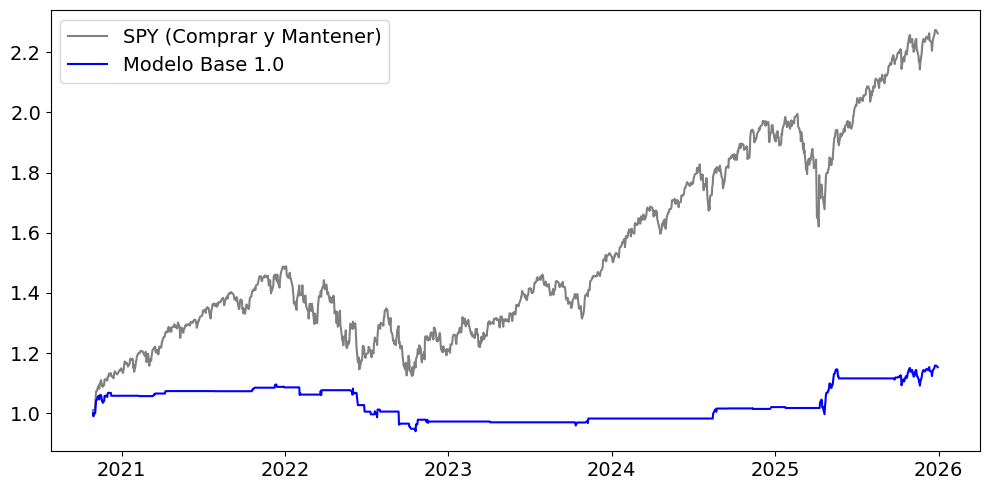


 6. Optimización: CLASIFICADOR DE VECTORES DE SOPORTE (SVC) Y BÚSQUEDA EN CUADRÍCULA
Iniciando Búsqueda en Cuadrícula (Grid Search)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

 ¡Optimización Completada!
Mejores Parámetros Encontrados: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}

 Resultados del pronóstico optimizado (FUERA DE MUESTRA)
Precisión Direccional Optimizada (t+1): 54.78%

Reporte de Clasificación:
              precision    recall  f1-score   support

    Baja (0)       0.00      0.00      0.00       587
    Alza (1)       0.55      1.00      0.71       711

    accuracy                           0.55      1298
   macro avg       0.27      0.50      0.35      1298
weighted avg       0.30      0.55      0.39      1298



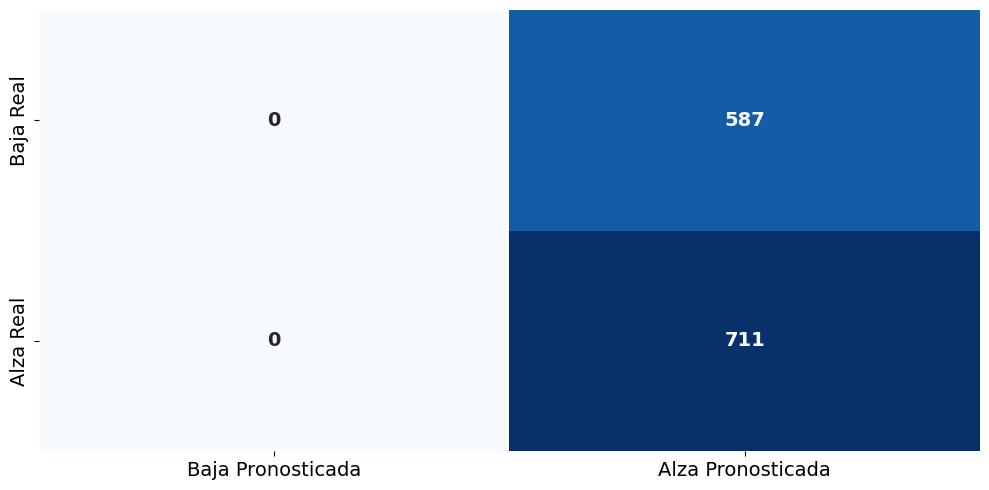

In [ ]:
# --- CANDADOS DE DETERMINISMO ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

# 1. EXTRACCIÓN DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
print("1. Cargando datos...")
ticker = "SPY"
archivo_csv = "datos_SPY_congelados.csv"

# EL TRUCO: Si ya existe el archivo local, lo lee. Si no, lo descarga y lo guarda para siempre.
if os.path.exists(archivo_csv):
    print("-> Leyendo datos congelados desde el disco duro (Sin internet)...")
    data = pd.read_csv(archivo_csv, index_col=0, parse_dates=True)
else:
    print("-> Descargando datos de Yahoo Finance por ÚLTIMA VEZ...")
    data = yf.download(ticker, start="2000-01-01", end="2025-12-31")
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    # Guardar en la computadora para congelar los números
    data.to_csv(archivo_csv)

# Identificar la columna de precio correcta
price_column = 'Adj Close'
if price_column not in data.columns:
    price_column = 'Close'

# Objetivo: Retornos Logarítmicos Diarios
data['Log_Return'] = np.log(data[price_column] / data[price_column].shift(1))

# Indicadores Técnicos (Momento y Tendencia)
data['SMA_15'] = data[price_column].rolling(window=15).mean()
data['SMA_50'] = data[price_column].rolling(window=50).mean()
data['Momentum_5D'] = data[price_column] / data[price_column].shift(5) - 1

# Indicadores Estadísticos (Volatilidad y Riesgo)
data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()
data['Roll_Skew_30'] = data['Log_Return'].rolling(window=30).skew()
data['Roll_Kurt_30'] = data['Log_Return'].rolling(window=30).kurt()

# Definiendo variables independientes (X) y variable dependiente (y)
feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30', 'Roll_Skew_30', 'Roll_Kurt_30']
X_raw = data[feature_cols]
y_raw = data['Log_Return']

# REZAGO: Previniendo el sesgo de anticipación (Alineando X en t-1 con y en t)
X_lagged = X_raw.shift(1)

# Fusionar y eliminar NaNs (Causados por las ventanas móviles y el rezago)
dataset = pd.concat([y_raw, X_lagged], axis=1).dropna()
y = dataset['Log_Return']
X = dataset[feature_cols]

# DIVISIÓN CRONOLÓGICA (80% Entrenamiento, 20% Prueba)
split_idx = int(len(dataset) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Datos Listos. Conjunto de Entrenamiento: {len(X_train)} días. Conjunto de Prueba: {len(X_test)} días.")

# 2. PASO 1: IDENTIFICACIÓN DE REGÍMENES (GHMM)
print("\n2. Entrenando GaussianHMM...")
# Entrenando el HMM usando retornos del conjunto de entrenamiento
hmm_train_data = y_train.values.reshape(-1, 1)
model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model_hmm.fit(hmm_train_data)

# Prediciendo regímenes
regimes_train = model_hmm.predict(hmm_train_data)
hmm_test_data = y_test.values.reshape(-1, 1)
regimes_test = model_hmm.predict(hmm_test_data)

# Añadir los regímenes como una nueva característica (señal estructural)
X_train['Regime'] = regimes_train
X_test['Regime'] = regimes_test
feature_cols.append('Regime') # Actualizar feature_cols para incluir 'Regime'

# 3. PASO 2: ELIMINACIÓN DE RUIDO Y SELECCIÓN DE CARACTERÍSTICAS (RANDOM FOREST)
print("3. Ejecutando Filtro Random Forest...")
# n_jobs=1 fuerza un solo hilo para garantizar determinismo estricto
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)

# Extrayendo importancias de características y aplicando umbral
importances = rf.feature_importances_
threshold = 0.05
important_features = []

print("\n Importancia de Características ")
for feature, imp in zip(feature_cols, importances):
    status = "CONSERVAR" if imp > threshold else "DESCARTAR"
    if status == "CONSERVAR": important_features.append(feature)
    print(f"{feature}: {imp:.4f} -> {status}")

X_train_filtered = X_train[important_features]
X_test_filtered = X_test[important_features]

# 4. PASO 3: PRONÓSTICO (REGRESIÓN DE VECTORES DE SOPORTE)
print("\n4. Entrenando SVR con características filtradas...")
# Nota: SVR es sensible a la escala; estandarizando los datos filtrados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_filtered)

svr = SVR(kernel='rbf', C=100, epsilon=0.001)
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

# 5. MÉTRICAS Y EVALUACIÓN
print("\n Resultados del Pronóstico")

# 5.1. RMSE (Raíz del Error Cuadrático Medio)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.6f}")

# 5.2. Precisión Direccional (¿Fue correcta la predicción de si el precio subía o bajaba?)
y_test_dir = np.where(y_test > 0, 1, 0)
y_pred_dir = np.where(y_pred > 0, 1, 0)
dir_acc = accuracy_score(y_test_dir, y_pred_dir)
print(f"Precisión Direccional (t+1): {dir_acc * 100:.2f}%")

# 5.3. BACKTESTING FINANCIERO: ESTRATEGIA SVR VS COMPRAR Y MANTENER
backtest_df_svr = pd.DataFrame(index=y_test.index)
backtest_df_svr['Market_Returns'] = y_test
backtest_df_svr['Signal'] = y_pred_dir

# El retorno de la estrategia usa la predicción de AYER para el retorno del mercado de HOY
backtest_df_svr['Strategy_Returns'] = backtest_df_svr['Market_Returns'] * backtest_df_svr['Signal'].shift(1)
backtest_df_svr.fillna(0, inplace=True)

backtest_df_svr['Cum_Market'] = np.exp(backtest_df_svr['Market_Returns'].cumsum())
backtest_df_svr['Cum_Strategy'] = np.exp(backtest_df_svr['Strategy_Returns'].cumsum())

total_mkt_svr = (backtest_df_svr['Cum_Market'].iloc[-1] - 1) * 100
total_str_svr = (backtest_df_svr['Cum_Strategy'].iloc[-1] - 1) * 100

max_dd_mkt_svr = ((backtest_df_svr['Cum_Market'] / backtest_df_svr['Cum_Market'].cummax()) - 1).min() * 100
max_dd_str_svr = ((backtest_df_svr['Cum_Strategy'] / backtest_df_svr['Cum_Strategy'].cummax()) - 1).min() * 100

sharpe_mkt_svr = np.sqrt(252) * (backtest_df_svr['Market_Returns'].mean() / backtest_df_svr['Market_Returns'].std())
sharpe_str_svr = np.sqrt(252) * (backtest_df_svr['Strategy_Returns'].mean() / backtest_df_svr['Strategy_Returns'].std())

print("\n RESULTADOS FINANCIEROS: ESTRATEGIA SVR")
print(f"Mercado    -> Retorno Total: {total_mkt_svr:.2f}% | Drawdown: {max_dd_mkt_svr:.2f}% | Sharpe: {sharpe_mkt_svr:.2f}")
print(f"Estrategia -> Retorno Total: {total_str_svr:.2f}% | Drawdown: {max_dd_str_svr:.2f}% | Sharpe: {sharpe_str_svr:.2f}\n")

plt.figure(figsize=(10, 5))
plt.plot(backtest_df_svr.index, backtest_df_svr['Cum_Market'], label=f'{ticker} (Comprar y Mantener)', color='gray')
plt.plot(backtest_df_svr.index, backtest_df_svr['Cum_Strategy'], label='Modelo Base 1.0', color='blue')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

print("\n 6. Optimización: CLASIFICADOR DE VECTORES DE SOPORTE (SVC) Y BÚSQUEDA EN CUADRÍCULA")

# 6.1. Transformar la variable objetivo en una clase binaria (Direccionalidad).
# 1 = Retorno Positivo (Alza), 0 = Retorno Negativo (Baja)
y_train_class = np.where(y_train > 0, 1, 0)
y_test_class = np.where(y_test > 0, 1, 0)

# 6.2. Validación Cruzada de Series Temporales (Evitando Sesgo de Anticipación)
tscv = TimeSeriesSplit(n_splits=5)

# 6.3. Espacio de búsqueda de hiperparámetros
param_grid = {
    'C': [0.1, 1, 10, 100],           # Término de penalización de error
    'gamma': ['scale', 'auto', 0.01, 0.1, 1], # Coeficiente para el Kernel RBF
    'kernel': ['rbf']                 # RBF para no linealidad financiera
}

print("Iniciando Búsqueda en Cuadrícula (Grid Search)...")

# 6.4. Instanciando el modelo base y el optimizador (n_jobs=1 para determinismo)
svc_base = SVC(random_state=42)
grid_search = GridSearchCV(
    estimator=svc_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy', # Optimizado para maximizar la Precisión Direccional
    n_jobs=1,
    verbose=1
)

# 6.5. Entrenar el optimizador
grid_search.fit(X_train_scaled, y_train_class)

# Extraer el mejor modelo
best_svc = grid_search.best_estimator_
print(f"\n ¡Optimización Completada!")
print(f"Mejores Parámetros Encontrados: {grid_search.best_params_}")

# 7. Evaluación del Modelo Optimizado (FUERA DE MUESTRA)
print("\n Resultados del pronóstico optimizado (FUERA DE MUESTRA)")

# Generar predicciones usando el modelo optimizado
y_pred_class = best_svc.predict(X_test_scaled)

# Calcular la nueva precisión direccional
opt_dir_acc = accuracy_score(y_test_class, y_pred_class)
print(f"Precisión Direccional Optimizada (t+1): {opt_dir_acc * 100:.2f}%\n")

# Reporte de clasificación detallado
print("Reporte de Clasificación:")
print(classification_report(y_test_class, y_pred_class, target_names=['Baja (0)', 'Alza (1)']))

# Matriz de Confusión
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(10, 5))

# El parámetro annot_kws ajusta el tamaño de los números DENTRO de la matriz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Baja Pronosticada', 'Alza Pronosticada'],
            yticklabels=['Baja Real', 'Alza Real'],
            annot_kws={"size": 14, "weight": "bold"}) # <--- Aquí controlas el texto interior

# plt.tick_params ajusta el tamaño de las etiquetas de los ejes (los nombres de las clases)
plt.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()

# Ultimate Baseline 2.0

1. Cargando datos...
-> Leyendo datos congelados desde el disco duro (Sin internet)...
Datos Listos. Conjunto de Entrenamiento: 5190 días. Conjunto de Prueba: 1298 días.

2. Entrenando GaussianHMM...
3. Ejecutando Filtro Random Forest...

 Importancia de Características 
SMA_15: 0.1018 -> CONSERVAR
SMA_50: 0.0875 -> CONSERVAR
Momentum_5D: 0.2241 -> CONSERVAR
Roll_Vol_15: 0.1697 -> CONSERVAR
Roll_Vol_30: 0.1396 -> CONSERVAR
Roll_Skew_30: 0.1403 -> CONSERVAR
Roll_Kurt_30: 0.1292 -> CONSERVAR
Regime: 0.0078 -> DESCARTAR

4. Entrenando SVR con características filtradas...

 Resultados del Pronóstico
RMSE (Raíz del Error Cuadrático Medio): 0.188265
Precisión Direccional (t+1): 47.69%

 RESULTADOS FINANCIEROS: ESTRATEGIA SVR
Mercado    -> Retorno Total: 126.26% | Drawdown: -24.50% | Sharpe: 0.93
Estrategia -> Retorno Total: 15.91% | Drawdown: -14.14% | Sharpe: 0.45



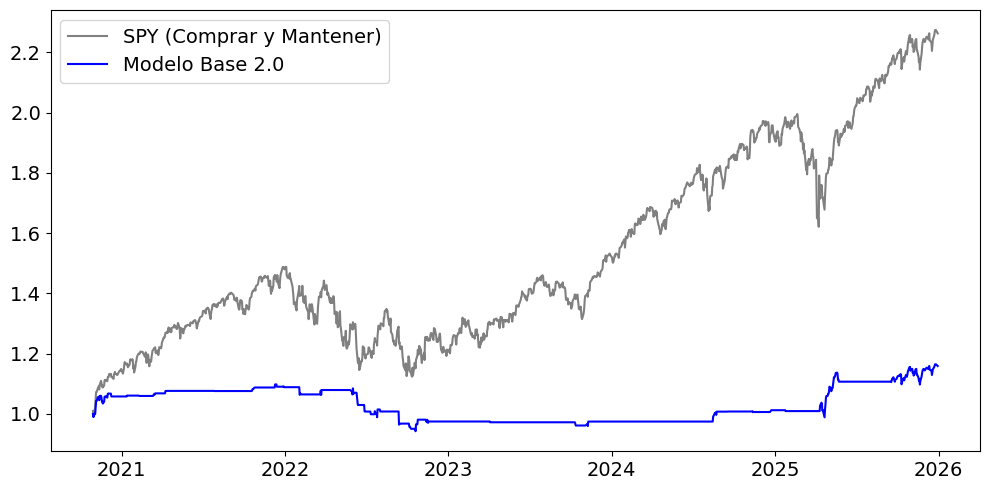


 6. Optimización: CLASIFICADOR DE VECTORES DE SOPORTE (SVC) Y BÚSQUEDA EN CUADRÍCULA
Iniciando Búsqueda en Cuadrícula (Grid Search)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

 ¡Optimización Completada!
Mejores Parámetros Encontrados: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}

 Resultados del pronóstico optimizado (FUERA DE MUESTRA)
Precisión Direccional Optimizada (t+1): 47.30%

Reporte de Clasificación:
              precision    recall  f1-score   support

    Baja (0)       0.45      0.83      0.59       587
    Alza (1)       0.56      0.18      0.27       711

    accuracy                           0.47      1298
   macro avg       0.51      0.50      0.43      1298
weighted avg       0.51      0.47      0.42      1298



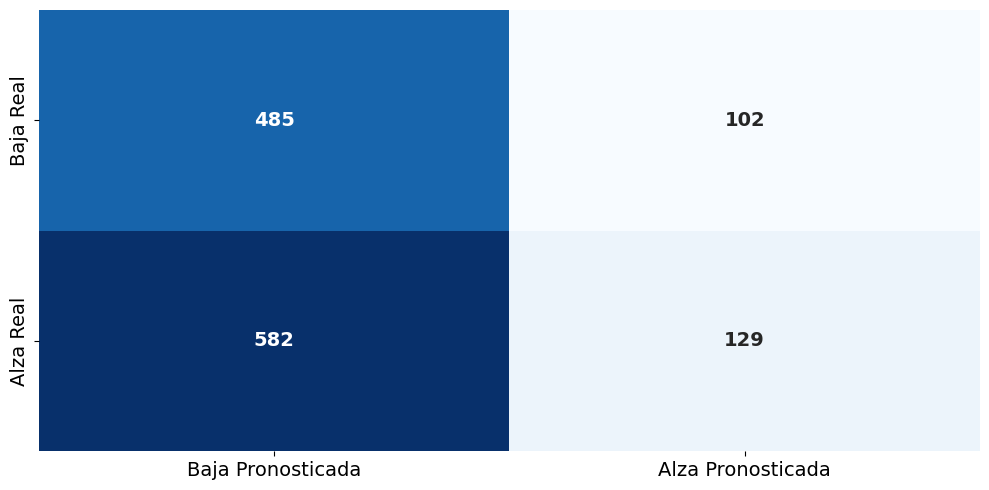

In [ ]:
# --- CANDADOS DE DETERMINISMO ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

# 1. EXTRACCIÓN DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
print("1. Cargando datos...")
ticker = "SPY"
archivo_csv = "/content/drive/MyDrive/datos_SPY_congelados.csv"

# EL TRUCO: Si ya existe el archivo local, lo lee. Si no, lo descarga y lo guarda para siempre.
if os.path.exists(archivo_csv):
    print("-> Leyendo datos congelados desde el disco duro (Sin internet)...")
    data = pd.read_csv(archivo_csv, index_col=0, parse_dates=True)
else:
    print("-> Descargando datos de Yahoo Finance por ÚLTIMA VEZ...")
    data = yf.download(ticker, start="2000-01-01", end="2025-12-31")
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    # Guardar en la computadora para congelar los números
    data.to_csv(archivo_csv)

# Identificar la columna de precio correcta
price_column = 'Adj Close'
if price_column not in data.columns:
    price_column = 'Close'

# Objetivo: Retornos Logarítmicos Diarios
data['Log_Return'] = np.log(data[price_column] / data[price_column].shift(1))

# Indicadores Técnicos (Momento y Tendencia)
data['SMA_15'] = data[price_column].rolling(window=15).mean()
data['SMA_50'] = data[price_column].rolling(window=50).mean()
data['Momentum_5D'] = data[price_column] / data[price_column].shift(5) - 1

# Indicadores Estadísticos (Volatilidad y Riesgo)
data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()
data['Roll_Skew_30'] = data['Log_Return'].rolling(window=30).skew()
data['Roll_Kurt_30'] = data['Log_Return'].rolling(window=30).kurt()

# Definiendo variables independientes (X) y variable dependiente (y)
feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30', 'Roll_Skew_30', 'Roll_Kurt_30']
X_raw = data[feature_cols]
y_raw = data['Log_Return']

# REZAGO: Previniendo el sesgo de anticipación (Alineando X en t-1 con y en t)
X_lagged = X_raw.shift(1)

# Fusionar y eliminar NaNs (Causados por las ventanas móviles y el rezago)
dataset = pd.concat([y_raw, X_lagged], axis=1).dropna()
y = dataset['Log_Return']
X = dataset[feature_cols]

# DIVISIÓN CRONOLÓGICA (80% Entrenamiento, 20% Prueba)
split_idx = int(len(dataset) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Datos Listos. Conjunto de Entrenamiento: {len(X_train)} días. Conjunto de Prueba: {len(X_test)} días.")

# 2. PASO 1: IDENTIFICACIÓN DE REGÍMENES (GHMM)
print("\n2. Entrenando GaussianHMM...")
# Entrenando el HMM usando retornos del conjunto de entrenamiento
hmm_train_data = y_train.values.reshape(-1, 1)
model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model_hmm.fit(hmm_train_data)

# Prediciendo regímenes
regimes_train = model_hmm.predict(hmm_train_data)
hmm_test_data = y_test.values.reshape(-1, 1)
regimes_test = model_hmm.predict(hmm_test_data)

# Añadir los regímenes como una nueva característica (señal estructural)
X_train['Regime'] = regimes_train
X_test['Regime'] = regimes_test
feature_cols.append('Regime') # Actualizar feature_cols para incluir 'Regime'

# 3. PASO 2: ELIMINACIÓN DE RUIDO Y SELECCIÓN DE CARACTERÍSTICAS (RANDOM FOREST)
print("3. Ejecutando Filtro Random Forest...")
# n_jobs=1 fuerza un solo hilo para garantizar determinismo estricto
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)

# Extrayendo importancias de características y aplicando umbral
importances = rf.feature_importances_
threshold = 0.05
important_features = []

print("\n Importancia de Características ")
for feature, imp in zip(feature_cols, importances):
    status = "CONSERVAR" if imp > threshold else "DESCARTAR"
    if status == "CONSERVAR": important_features.append(feature)
    print(f"{feature}: {imp:.4f} -> {status}")

X_train_filtered = X_train[important_features]
X_test_filtered = X_test[important_features]

# 4. PASO 3: PRONÓSTICO (REGRESIÓN DE VECTORES DE SOPORTE)
print("\n4. Entrenando SVR con características filtradas...")
# Nota: SVR es sensible a la escala; estandarizando los datos filtrados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_filtered)

svr = SVR(kernel='rbf', C=100, epsilon=0.001)
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

# 5. MÉTRICAS Y EVALUACIÓN
print("\n Resultados del Pronóstico")

# 5.1. RMSE (Raíz del Error Cuadrático Medio)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.6f}")

# 5.2. Precisión Direccional (¿Fue correcta la predicción de si el precio subía o bajaba?)
y_test_dir = np.where(y_test > 0, 1, 0)
y_pred_dir = np.where(y_pred > 0, 1, 0)
dir_acc = accuracy_score(y_test_dir, y_pred_dir)
print(f"Precisión Direccional (t+1): {dir_acc * 100:.2f}%")

# 5.3. BACKTESTING FINANCIERO: ESTRATEGIA SVR VS COMPRAR Y MANTENER
backtest_df_svr = pd.DataFrame(index=y_test.index)
backtest_df_svr['Market_Returns'] = y_test
backtest_df_svr['Signal'] = y_pred_dir

# El retorno de la estrategia usa la predicción de AYER para el retorno del mercado de HOY
backtest_df_svr['Strategy_Returns'] = backtest_df_svr['Market_Returns'] * backtest_df_svr['Signal'].shift(1)
backtest_df_svr.fillna(0, inplace=True)

backtest_df_svr['Cum_Market'] = np.exp(backtest_df_svr['Market_Returns'].cumsum())
backtest_df_svr['Cum_Strategy'] = np.exp(backtest_df_svr['Strategy_Returns'].cumsum())

total_mkt_svr = (backtest_df_svr['Cum_Market'].iloc[-1] - 1) * 100
total_str_svr = (backtest_df_svr['Cum_Strategy'].iloc[-1] - 1) * 100

max_dd_mkt_svr = ((backtest_df_svr['Cum_Market'] / backtest_df_svr['Cum_Market'].cummax()) - 1).min() * 100
max_dd_str_svr = ((backtest_df_svr['Cum_Strategy'] / backtest_df_svr['Cum_Strategy'].cummax()) - 1).min() * 100

sharpe_mkt_svr = np.sqrt(252) * (backtest_df_svr['Market_Returns'].mean() / backtest_df_svr['Market_Returns'].std())
sharpe_str_svr = np.sqrt(252) * (backtest_df_svr['Strategy_Returns'].mean() / backtest_df_svr['Strategy_Returns'].std())

print("\n RESULTADOS FINANCIEROS: ESTRATEGIA SVR")
print(f"Mercado    -> Retorno Total: {total_mkt_svr:.2f}% | Drawdown: {max_dd_mkt_svr:.2f}% | Sharpe: {sharpe_mkt_svr:.2f}")
print(f"Estrategia -> Retorno Total: {total_str_svr:.2f}% | Drawdown: {max_dd_str_svr:.2f}% | Sharpe: {sharpe_str_svr:.2f}\n")

plt.figure(figsize=(10, 5))
plt.plot(backtest_df_svr.index, backtest_df_svr['Cum_Market'], label=f'{ticker} (Comprar y Mantener)', color='gray')
plt.plot(backtest_df_svr.index, backtest_df_svr['Cum_Strategy'], label='Modelo Base 2.0', color='blue')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

print("\n 6. Optimización: CLASIFICADOR DE VECTORES DE SOPORTE (SVC) Y BÚSQUEDA EN CUADRÍCULA")

# 6.1. Transformar la variable objetivo en una clase binaria (Direccionalidad).
# 1 = Retorno Positivo (Alza), 0 = Retorno Negativo (Baja)
y_train_class = np.where(y_train > 0, 1, 0)
y_test_class = np.where(y_test > 0, 1, 0)

# 6.2. Validación Cruzada de Series Temporales (Evitando Sesgo de Anticipación)
tscv = TimeSeriesSplit(n_splits=5)

# 6.3. Espacio de búsqueda de hiperparámetros
param_grid = {
    'C': [0.1, 1, 10, 100],           # Término de penalización de error
    'gamma': ['scale', 'auto', 0.01, 0.1, 1], # Coeficiente para el Kernel RBF
    'kernel': ['rbf']                 # RBF para no linealidad financiera
}

print("Iniciando Búsqueda en Cuadrícula (Grid Search)...")

# 6.4 Inicializar el modelo base y el optimizador (n_jobs=1 para determinismo)
svc_base = SVC(class_weight='balanced', random_state=42)
grid_search = GridSearchCV(
    estimator=svc_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='balanced_accuracy', # Buscamos maximizar la Precisión Direccional Balanceada
    n_jobs=1,
    verbose=1
)

# 6.5. Entrenar el optimizador
grid_search.fit(X_train_scaled, y_train_class)

# Extraer el mejor modelo
best_svc = grid_search.best_estimator_
print(f"\n ¡Optimización Completada!")
print(f"Mejores Parámetros Encontrados: {grid_search.best_params_}")

# 7. Evaluación del Modelo Optimizado (FUERA DE MUESTRA)
print("\n Resultados del pronóstico optimizado (FUERA DE MUESTRA)")

# Generar predicciones usando el modelo optimizado
y_pred_class = best_svc.predict(X_test_scaled)

# Calcular la nueva precisión direccional
opt_dir_acc = accuracy_score(y_test_class, y_pred_class)
print(f"Precisión Direccional Optimizada (t+1): {opt_dir_acc * 100:.2f}%\n")

# Reporte de clasificación detallado
print("Reporte de Clasificación:")
print(classification_report(y_test_class, y_pred_class, target_names=['Baja (0)', 'Alza (1)']))

# Matriz de Confusión
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Baja Pronosticada', 'Alza Pronosticada'],
            yticklabels=['Baja Real', 'Alza Real'],
            annot_kws={"size": 14, "weight": "bold"}) # <--- Aquí controlas el texto interior

plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# Ultimate Baseline 3.0

1. Cargando datos...
-> Leyendo datos congelados desde el disco duro (Sin internet)...
 2. MODELO SVC PENALIZADO (MODELO BASE 3.0)

 Métricas y Evaluación (Dentro de Muestra vs Fuera de Muestra)
Precisión Direccional de Entrenamiento: 54.04%
RMSE de Entrenamiento: 0.677969
Precisión Direccional Fuera de Muestra: 49.85%
RMSE Fuera de Muestra: 0.708195

Reporte de Clasificación (Enfocado en Riesgo):
              precision    recall  f1-score   support

    Baja (0)       0.46      0.64      0.54       588
    Alza (1)       0.56      0.38      0.45       710

    accuracy                           0.50      1298
   macro avg       0.51      0.51      0.49      1298
weighted avg       0.52      0.50      0.49      1298



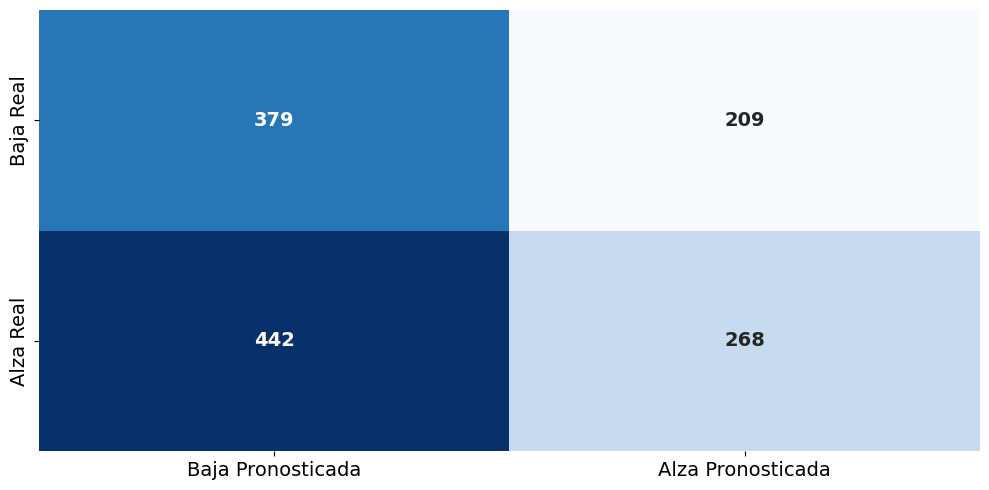

 3. BACKTESTING FINANCIERO: ESTRATEGIA VS COMPRAR Y MANTENER

 RESULTADOS FINANCIEROS: ESTRATEGIA SVC PENALIZADA
Mercado    -> Retorno Total: 126.26% | Drawdown: -24.50% | Sharpe: 0.93
Estrategia -> Retorno Total: 26.19% | Drawdown: -18.76% | Sharpe: 0.41



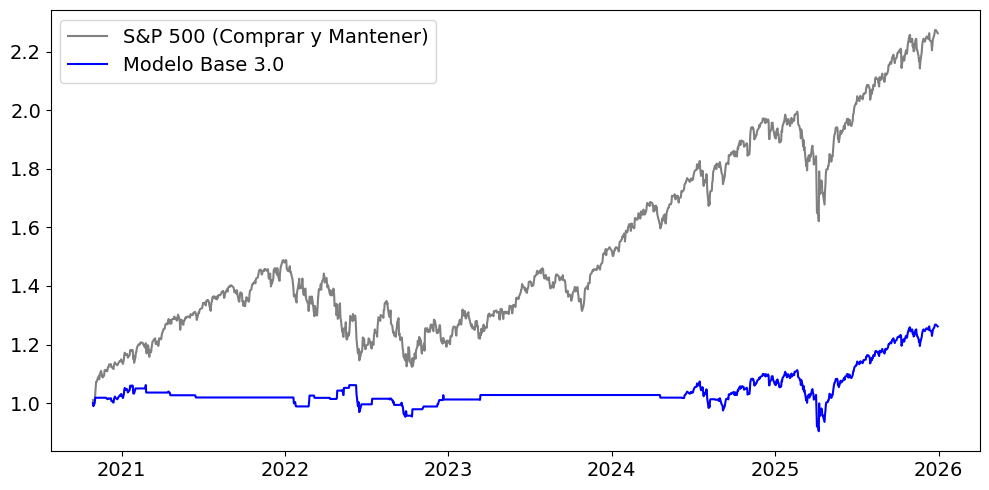

In [ ]:
# --- CANDADOS DE DETERMINISMO ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

# 1. EXTRACCIÓN DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
print("1. Cargando datos...")
ticker = "SPY"
archivo_csv = "/content/drive/MyDrive/datos_SPY_congelados.csv"
# EL TRUCO: Si ya existe el archivo local, lo lee. Si no, lo descarga y lo guarda para siempre.
if os.path.exists(archivo_csv):
    print("-> Leyendo datos congelados desde el disco duro (Sin internet)...")
    data = pd.read_csv(archivo_csv, index_col=0, parse_dates=True)
else:
    print("-> Descargando datos de Yahoo Finance por ÚLTIMA VEZ...")
    data = yf.download(ticker, start="2000-01-01", end="2025-12-31")
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    # Guardar en la computadora para congelar los números
    data.to_csv(archivo_csv)

# Identificar la columna de precio correcta
price_column = 'Adj Close'
if price_column not in data.columns:
    price_column = 'Close'

# Objetivo: Retornos Logarítmicos Diarios
data['Log_Return'] = np.log(data[price_column] / data[price_column].shift(1))
data['Target_Dir'] = np.where(data['Log_Return'].shift(-1) > 0, 1, 0)

# Ingeniería de Características
data['SMA_15'] = data[price_column].rolling(window=15).mean()
data['SMA_50'] = data[price_column].rolling(window=50).mean()
data['Momentum_5D'] = data[price_column] / data[price_column].shift(5) - 1
data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()

# Limpieza y división de características
feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30']
dataset = data[feature_cols + ['Log_Return', 'Target_Dir']].dropna()

X = dataset[feature_cols]
y_class = dataset['Target_Dir']
y_returns = dataset['Log_Return']

split_idx = int(len(dataset) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_class, y_test_class = y_class.iloc[:split_idx], y_class.iloc[split_idx:]
y_test_returns = y_returns.iloc[split_idx:] # Extraído para el backtesting

print(" 2. MODELO SVC PENALIZADO (MODELO BASE 3.0)")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'C': [1, 10, 100], 'gamma': ['auto', 0.01, 0.1]}
svc_base = SVC(class_weight='balanced', random_state=42)

# n_jobs=1 para garantizar determinismo estricto
grid_search = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
grid_search.fit(X_train_scaled, y_train_class)

best_svc = grid_search.best_estimator_

# Generar predicciones tanto para Entrenamiento como para Prueba para comparar métricas
y_pred_train = best_svc.predict(X_train_scaled)
y_pred_class = best_svc.predict(X_test_scaled)

print("\n Métricas y Evaluación (Dentro de Muestra vs Fuera de Muestra)")

# 2.1 Métricas de Entrenamiento (In-Sample)
train_acc = accuracy_score(y_train_class, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train_class, y_pred_train))
print(f"Precisión Direccional de Entrenamiento: {train_acc * 100:.2f}%")
print(f"RMSE de Entrenamiento: {train_rmse:.6f}")

# 2.2 Métricas de Prueba (Out-of-Sample)
test_acc = accuracy_score(y_test_class, y_pred_class)
test_rmse = np.sqrt(mean_squared_error(y_test_class, y_pred_class))
print(f"Precisión Direccional Fuera de Muestra: {test_acc * 100:.2f}%")
print(f"RMSE Fuera de Muestra: {test_rmse:.6f}\n")

print("Reporte de Clasificación (Enfocado en Riesgo):")
print(classification_report(y_test_class, y_pred_class, target_names=['Baja (0)', 'Alza (1)']))

# MATRIZ DE CONFUSIÓN VISUAL
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=['Baja Pronosticada', 'Alza Pronosticada'],
            yticklabels=['Baja Real', 'Alza Real'],
            annot_kws={"size": 14, "weight": "bold"}) # <--- Aquí controlas el texto interior
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

print(" 3. BACKTESTING FINANCIERO: ESTRATEGIA VS COMPRAR Y MANTENER")
backtest_df = pd.DataFrame(index=y_test_class.index)
backtest_df['Market_Returns'] = y_test_returns
backtest_df['Signal'] = y_pred_class

# El retorno de la estrategia usa la predicción de AYER para el retorno del mercado de HOY
backtest_df['Strategy_Returns'] = backtest_df['Market_Returns'] * backtest_df['Signal'].shift(1)
backtest_df.fillna(0, inplace=True)

backtest_df['Cum_Market'] = np.exp(backtest_df['Market_Returns'].cumsum())
backtest_df['Cum_Strategy'] = np.exp(backtest_df['Strategy_Returns'].cumsum())

total_mkt = (backtest_df['Cum_Market'].iloc[-1] - 1) * 100
total_str = (backtest_df['Cum_Strategy'].iloc[-1] - 1) * 100

max_dd_mkt = ((backtest_df['Cum_Market'] / backtest_df['Cum_Market'].cummax()) - 1).min() * 100
max_dd_str = ((backtest_df['Cum_Strategy'] / backtest_df['Cum_Strategy'].cummax()) - 1).min() * 100

# Cálculos del Ratio de Sharpe añadidos para coincidir con el Modelo Base 4.0
sharpe_mkt = np.sqrt(252) * (backtest_df['Market_Returns'].mean() / backtest_df['Market_Returns'].std())
sharpe_str = np.sqrt(252) * (backtest_df['Strategy_Returns'].mean() / backtest_df['Strategy_Returns'].std())

print("\n RESULTADOS FINANCIEROS: ESTRATEGIA SVC PENALIZADA")
print(f"Mercado    -> Retorno Total: {total_mkt:.2f}% | Drawdown: {max_dd_mkt:.2f}% | Sharpe: {sharpe_mkt:.2f}")
print(f"Estrategia -> Retorno Total: {total_str:.2f}% | Drawdown: {max_dd_str:.2f}% | Sharpe: {sharpe_str:.2f}\n")

plt.figure(figsize=(10, 5))
plt.plot(backtest_df.index, backtest_df['Cum_Market'], label='S&P 500 (Comprar y Mantener)', color='gray')
plt.plot(backtest_df.index, backtest_df['Cum_Strategy'], label='Modelo Base 3.0', color='blue')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# ULTIMATE BASELINE 4.0

1. Cargando datos...
-> Leyendo datos congelados desde el disco duro (Sin internet)...

1. Entrenando GaussianHMM para la Identificación de Regímenes...


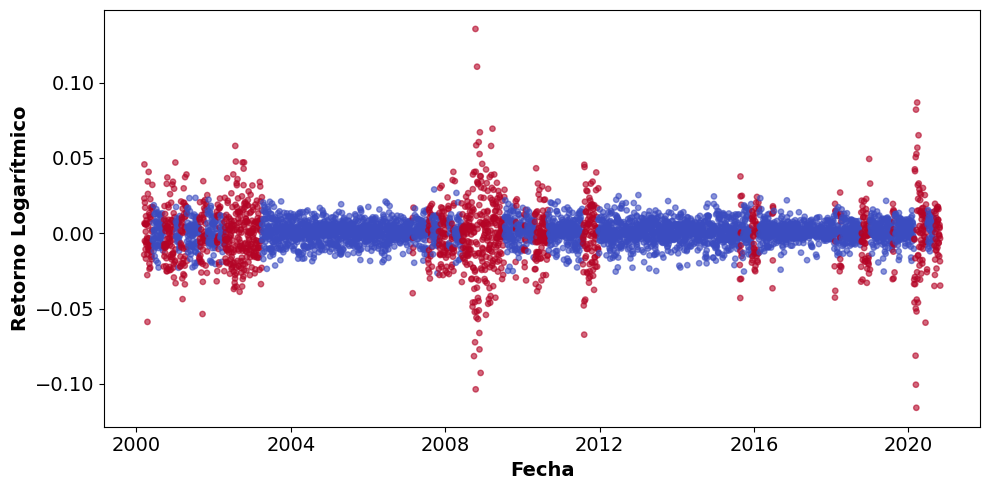


[Adición Visual] Entrenando Random Forest para Importancia de Características...


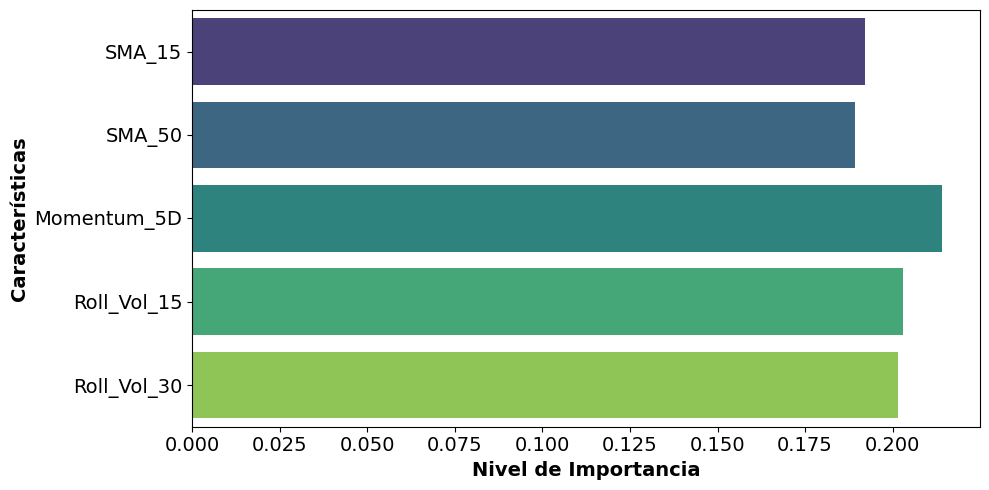


2. Particionando Datos Horizontalmente por Régimen de Mercado...
3. Entrenando Clasificadores de Vectores de Soporte Localizados...
   -> Optimizando SVC para el Régimen 0 (n=3787 días)
   -> Optimizando SVC para el Régimen 1 (n=1404 días)

4. Ejecutando Enrutamiento Dinámico Fuera de Muestra...

 Métricas y Evaluación (Dentro de Muestra vs Fuera de Muestra)
Precisión Direccional de Entrenamiento: 54.48%
RMSE de Entrenamiento: 0.674693
Precisión Direccional Fuera de Muestra: 56.47%
RMSE Fuera de Muestra: 0.659761

Reporte de Clasificación (Enfocado en Riesgo):
              precision    recall  f1-score   support

    Baja (0)       0.56      0.19      0.28       588
    Alza (1)       0.57      0.87      0.69       710

    accuracy                           0.56      1298
   macro avg       0.56      0.53      0.49      1298
weighted avg       0.56      0.56      0.50      1298



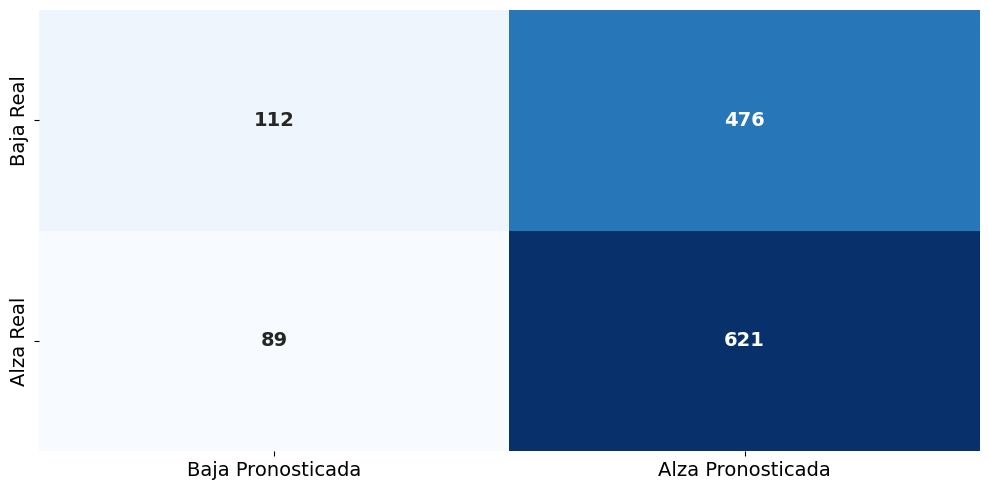


 RESULTADOS FINANCIEROS: ESTRATEGIA JERÁRQUICA PURA
Mercado    -> Retorno Total: 126.26% | Drawdown: -24.50% | Sharpe: 0.93
Estrategia -> Retorno Total: 199.97% | Drawdown: -17.20% | Sharpe: 1.55


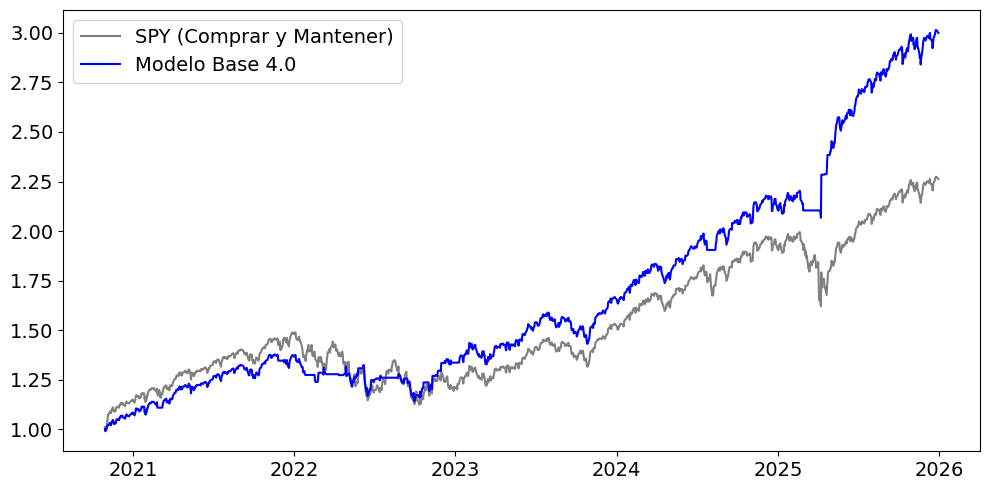

In [ ]:
# --- CANDADOS DE DETERMINISMO ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

# 1. EXTRACCIÓN DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
print("1. Cargando datos...")
ticker = "SPY"
archivo_csv = "/content/drive/MyDrive/datos_SPY_congelados.csv"

# EL TRUCO: Si ya existe el archivo local, lo lee. Si no, lo descarga y lo guarda para siempre.
if os.path.exists(archivo_csv):
    print("-> Leyendo datos congelados desde el disco duro (Sin internet)...")
    data = pd.read_csv(archivo_csv, index_col=0, parse_dates=True)
else:
    print("-> Descargando datos de Yahoo Finance por ÚLTIMA VEZ...")
    data = yf.download(ticker, start="2000-01-01", end="2025-12-31")
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    # Guardar en la computadora para congelar los números
    data.to_csv(archivo_csv)

# Identificar la columna de precio correcta
price_column = 'Adj Close'
if price_column not in data.columns:
    price_column = 'Close'

# Objetivo: Retornos Logarítmicos Diarios
data['Log_Return'] = np.log(data[price_column] / data[price_column].shift(1))
data['Target_Dir'] = np.where(data['Log_Return'].shift(-1) > 0, 1, 0)

# Ingeniería de Características
data['SMA_15'] = data[price_column].rolling(window=15).mean()
data['SMA_50'] = data[price_column].rolling(window=50).mean()
data['Momentum_5D'] = data[price_column] / data[price_column].shift(5) - 1
data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()

feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30']
dataset = data[feature_cols + ['Log_Return', 'Target_Dir']].dropna()

# División Cronológica (80% Entrenamiento, 20% Prueba)
split_idx = int(len(dataset) * 0.8)
train_data = dataset.iloc[:split_idx].copy()
test_data = dataset.iloc[split_idx:].copy()

X_train = train_data[feature_cols]
y_train_class = train_data['Target_Dir']
X_test = test_data[feature_cols]
y_test_class = test_data['Target_Dir']
y_test_returns = test_data['Log_Return']

# ETAPA 1: IDENTIFICACIÓN DE REGÍMENES (El Enrutador Cronológico)
print("\n1. Entrenando GaussianHMM para la Identificación de Regímenes...")
hmm_train_data = train_data['Log_Return'].values.reshape(-1, 1)
model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model_hmm.fit(hmm_train_data)

# Predecir regímenes para los conjuntos de Entrenamiento y Prueba
regimes_train = model_hmm.predict(hmm_train_data)
regimes_test = model_hmm.predict(test_data['Log_Return'].values.reshape(-1, 1))

# VISUALIZAR REGÍMENES GHMM
plt.figure(figsize=(10, 5))
plt.scatter(train_data.index, train_data['Log_Return'], c=regimes_train, cmap='coolwarm', alpha=0.6, s=15)
plt.xlabel('Fecha', fontsize=14, fontweight='bold')
plt.ylabel('Retorno Logarítmico', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# VISUALIZAR IMPORTANCIA DE CARACTERÍSTICAS (RANDOM FOREST)
# (Añadido puramente para visualización, sin alterar las características del pipeline)
print("\n[Adición Visual] Entrenando Random Forest para Importancia de Características...")
# n_jobs=1 para evitar aleatoriedad en los decimales
rf_vis = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
rf_vis.fit(X_train, y_train_class)

plt.figure(figsize=(10, 5))
sns.barplot(x=rf_vis.feature_importances_, y=feature_cols, palette='viridis')
plt.xlabel('Nivel de Importancia', fontsize=14, fontweight='bold')
plt.ylabel('Características', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# ETAPA 2: DIVISIÓN JERÁRQUICA Y ESCALADO LOCALIZADO
print("\n2. Particionando Datos Horizontalmente por Régimen de Mercado...")
# Segmentar Datos de Entrenamiento
X_train_R0, y_train_R0 = X_train[regimes_train == 0], y_train_class[regimes_train == 0]
X_train_R1, y_train_R1 = X_train[regimes_train == 1], y_train_class[regimes_train == 1]

# Escalado Localizado (Crucial para la convergencia de SVM)
scaler_R0 = StandardScaler().fit(X_train_R0)
scaler_R1 = StandardScaler().fit(X_train_R1)

X_train_R0_scaled = scaler_R0.transform(X_train_R0)
X_train_R1_scaled = scaler_R1.transform(X_train_R1)

# ETAPA 3: ENTRENAMIENTO DE SVC LOCALIZADO Y PENALIZADO
print("3. Entrenando Clasificadores de Vectores de Soporte Localizados...")
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'C': [1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.1]}
svc_base = SVC(class_weight='balanced', random_state=42)

# Entrenar Experto para el Régimen 0 (n_jobs=1 por determinismo)
print(f"   -> Optimizando SVC para el Régimen 0 (n={len(X_train_R0)} días)")
grid_R0 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
grid_R0.fit(X_train_R0_scaled, y_train_R0)
best_svc_R0 = grid_R0.best_estimator_

# Entrenar Experto para el Régimen 1 (n_jobs=1 por determinismo)
print(f"   -> Optimizando SVC para el Régimen 1 (n={len(X_train_R1)} días)")
grid_R1 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
grid_R1.fit(X_train_R1_scaled, y_train_R1)
best_svc_R1 = grid_R1.best_estimator_

# ENRUTAMIENTO DINÁMICO DENTRO DE MUESTRA (Para Métricas de Entrenamiento)
y_pred_train_class = np.zeros(len(X_train))
for i in range(len(X_train)):
    current_regime = regimes_train[i]
    current_features = X_train.iloc[i].values.reshape(1, -1)

    if current_regime == 0:
        scaled_features = scaler_R0.transform(current_features)
        y_pred_train_class[i] = best_svc_R0.predict(scaled_features)[0]
    else:
        scaled_features = scaler_R1.transform(current_features)
        y_pred_train_class[i] = best_svc_R1.predict(scaled_features)[0]

# ENRUTAMIENTO DINÁMICO Y PREDICCIÓN FUERA DE MUESTRA
print("\n4. Ejecutando Enrutamiento Dinámico Fuera de Muestra...")
y_pred_class = np.zeros(len(X_test))

# Enrutamos cada día de prueba al experto localizado correcto
for i in range(len(X_test)):
    current_regime = regimes_test[i]
    current_features = X_test.iloc[i].values.reshape(1, -1)

    if current_regime == 0:
        scaled_features = scaler_R0.transform(current_features)
        y_pred_class[i] = best_svc_R0.predict(scaled_features)[0]
    else:
        scaled_features = scaler_R1.transform(current_features)
        y_pred_class[i] = best_svc_R1.predict(scaled_features)[0]

# MÉTRICAS Y EVALUACIÓN
print("\n Métricas y Evaluación (Dentro de Muestra vs Fuera de Muestra)")

# Métricas de Entrenamiento (In-Sample)
train_acc = accuracy_score(y_train_class, y_pred_train_class)
train_rmse = np.sqrt(mean_squared_error(y_train_class, y_pred_train_class))
print(f"Precisión Direccional de Entrenamiento: {train_acc * 100:.2f}%")
print(f"RMSE de Entrenamiento: {train_rmse:.6f}")

# Métricas de Prueba (Out-of-Sample)
test_acc = accuracy_score(y_test_class, y_pred_class)
test_rmse = np.sqrt(mean_squared_error(y_test_class, y_pred_class))
print(f"Precisión Direccional Fuera de Muestra: {test_acc * 100:.2f}%")
print(f"RMSE Fuera de Muestra: {test_rmse:.6f}\n")

print("Reporte de Clasificación (Enfocado en Riesgo):")
print(classification_report(y_test_class, y_pred_class, target_names=['Baja (0)', 'Alza (1)']))

# MATRIZ DE CONFUSIÓN VISUAL
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=['Baja Pronosticada', 'Alza Pronosticada'],
            yticklabels=['Baja Real', 'Alza Real'],
            annot_kws={"size": 14, "weight": "bold"}) # <--- Aquí controlas el texto interior
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# BACKTESTING FINANCIERO
backtest_df = pd.DataFrame(index=y_test_class.index)
backtest_df['Market_Returns'] = y_test_returns
backtest_df['Signal'] = y_pred_class

# El retorno de la estrategia usa la señal de AYER para el retorno de HOY
backtest_df['Strategy_Returns'] = backtest_df['Market_Returns'] * backtest_df['Signal'].shift(1)
backtest_df.fillna(0, inplace=True)

backtest_df['Cum_Market'] = np.exp(backtest_df['Market_Returns'].cumsum())
backtest_df['Cum_Strategy'] = np.exp(backtest_df['Strategy_Returns'].cumsum())

# --- CÁLCULOS DE RETORNO TOTAL AÑADIDOS AQUÍ ---
total_ret_mkt = (backtest_df['Cum_Market'].iloc[-1] - 1) * 100
total_ret_str = (backtest_df['Cum_Strategy'].iloc[-1] - 1) * 100

max_dd_mkt = ((backtest_df['Cum_Market'] / backtest_df['Cum_Market'].cummax()) - 1).min() * 100
max_dd_str = ((backtest_df['Cum_Strategy'] / backtest_df['Cum_Strategy'].cummax()) - 1).min() * 100

sharpe_mkt = np.sqrt(252) * (backtest_df['Market_Returns'].mean() / backtest_df['Market_Returns'].std())
sharpe_str = np.sqrt(252) * (backtest_df['Strategy_Returns'].mean() / backtest_df['Strategy_Returns'].std())

print("\n RESULTADOS FINANCIEROS: ESTRATEGIA JERÁRQUICA PURA")
# --- SENTENCIAS PRINT ACTUALIZADAS AQUÍ ---
print(f"Mercado    -> Retorno Total: {total_ret_mkt:.2f}% | Drawdown: {max_dd_mkt:.2f}% | Sharpe: {sharpe_mkt:.2f}")
print(f"Estrategia -> Retorno Total: {total_ret_str:.2f}% | Drawdown: {max_dd_str:.2f}% | Sharpe: {sharpe_str:.2f}")

plt.figure(figsize=(10,5))
plt.plot(backtest_df.index, backtest_df['Cum_Market'], label=f'{ticker} (Comprar y Mantener)', color='gray')
plt.plot(backtest_df.index, backtest_df['Cum_Strategy'], label='Modelo Base 4.0', color='blue')
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# Ultimate baseline 4.0 all together

 BACKTEST DE PIPELINE JERÁRQUICO MULTI-ACTIVO

PROCESANDO TICKER: QQQ (1/8)...
   -> Descargando datos de QQQ por ÚLTIMA VEZ...
--- MÉTRICAS PARA QQQ ---
Dentro de Muestra -> Prec. Dir.: 51.34% | RMSE: 0.697575
Fuera de Muestra  -> Prec. Dir.: 57.70% | RMSE: 0.650353
Mercado           -> Retorno:  135.41% | Max DD:  -35.12% | Sharpe: 0.74
Estrategia        -> Retorno:  280.83% | Max DD:  -16.22% | Sharpe: 1.65

PROCESANDO TICKER: IWM (2/8)...
   -> Descargando datos de IWM por ÚLTIMA VEZ...


--- MÉTRICAS PARA IWM ---
Dentro de Muestra -> Prec. Dir.: 54.17% | RMSE: 0.676991
Fuera de Muestra  -> Prec. Dir.: 50.63% | RMSE: 0.702667
Mercado           -> Retorno:   44.11% | Max DD:  -31.91% | Sharpe: 0.32
Estrategia        -> Retorno:   47.09% | Max DD:  -22.04% | Sharpe: 0.47

PROCESANDO TICKER: EEM (3/8)...
   -> Descargando datos de EEM por ÚLTIMA VEZ...


--- MÉTRICAS PARA EEM ---
Dentro de Muestra -> Prec. Dir.: 52.31% | RMSE: 0.690613
Fuera de Muestra  -> Prec. Dir.: 50.00% | RMSE: 0.707107
Mercado           -> Retorno:   11.57% | Max DD:  -37.49% | Sharpe: 0.13
Estrategia        -> Retorno:   12.10% | Max DD:  -18.78% | Sharpe: 0.32

PROCESANDO TICKER: GLD (4/8)...
   -> Descargando datos de GLD por ÚLTIMA VEZ...
--- MÉTRICAS PARA GLD ---
Dentro de Muestra -> Prec. Dir.: 58.29% | RMSE: 0.645834
Fuera de Muestra  -> Prec. Dir.: 51.85% | RMSE: 0.693889
Mercado           -> Retorno:  141.09% | Max DD:  -21.03% | Sharpe: 1.33
Estrategia        -> Retorno:   83.91% | Max DD:  -10.63% | Sharpe: 1.41

PROCESANDO TICKER: TLT (5/8)...
   -> Descargando datos de TLT por ÚLTIMA VEZ...
--- MÉTRICAS PARA TLT ---
Dentro de Muestra -> Prec. Dir.: 54.73% | RMSE: 0.672858
Fuera de Muestra  -> Prec. Dir.: 50.90% | RMSE: 0.700727
Mercado           -> Retorno:  -26.83% | Max DD:  -43.70% | Sharpe: -0.41
Estrategia        -> Retorno:    7.47% | Max DD:  

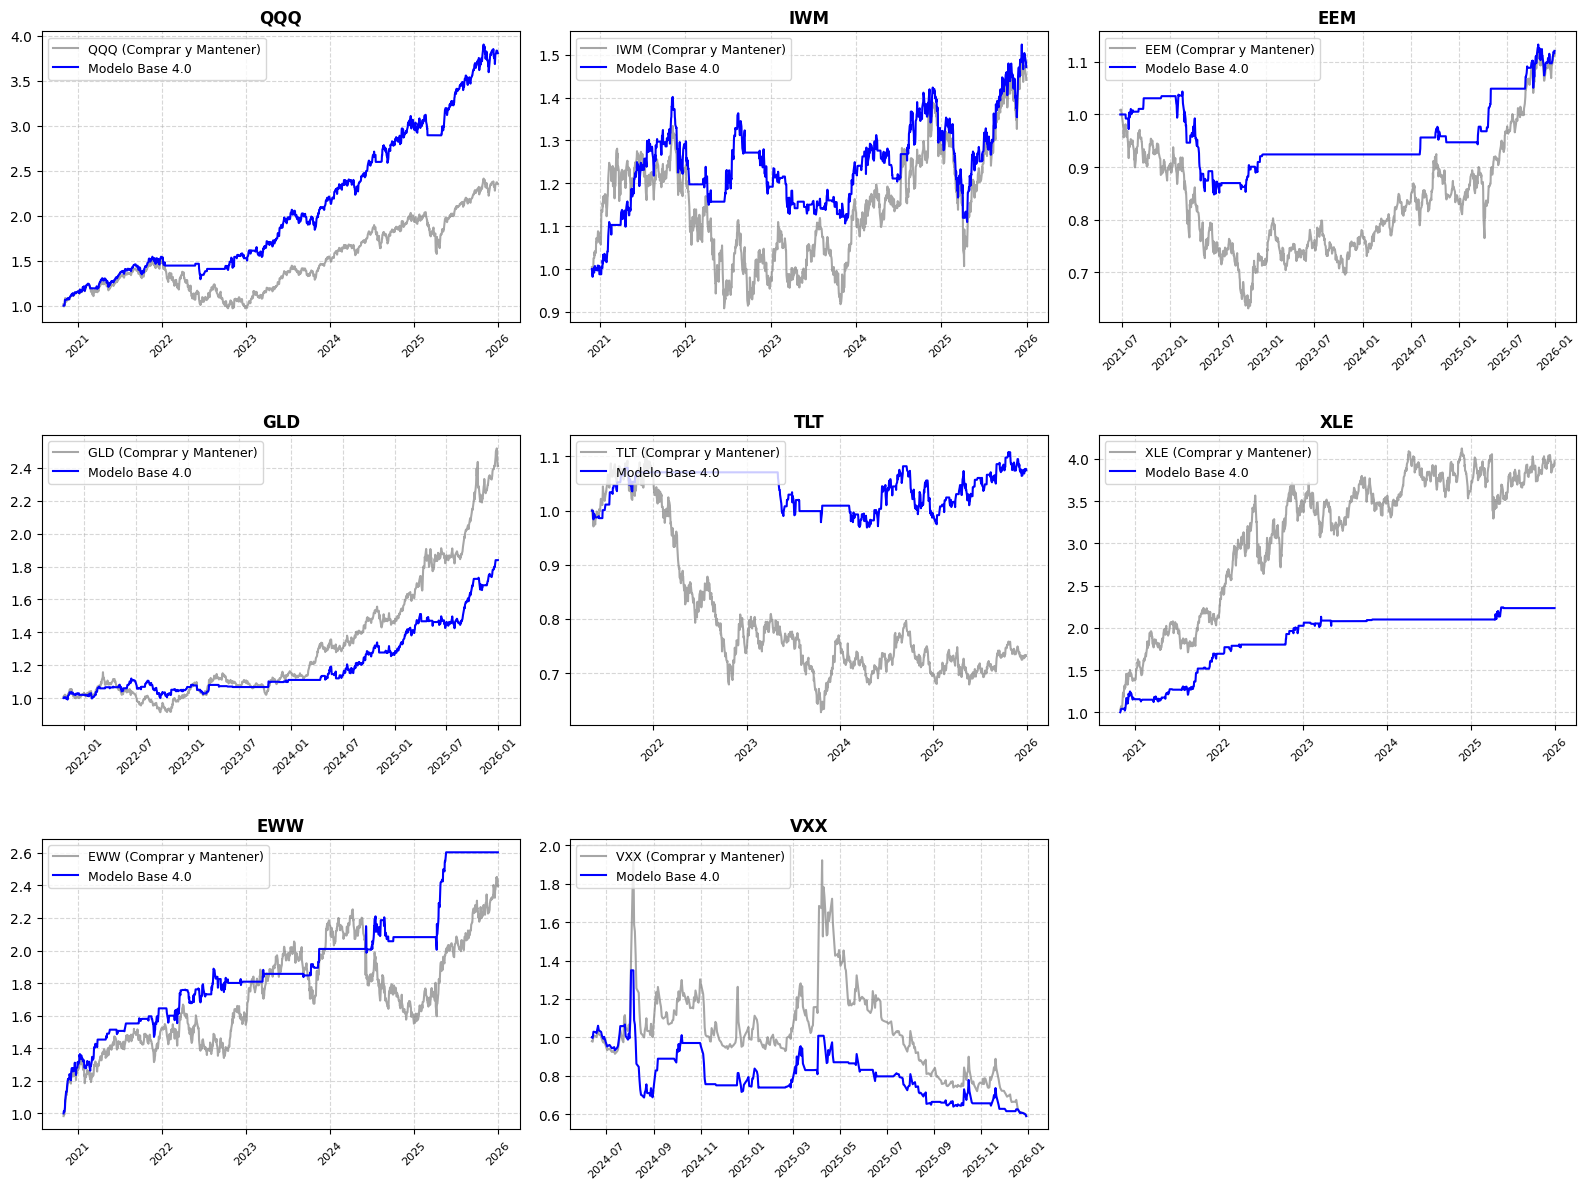

In [ ]:
# --- 1. CANDADOS DE DETERMINISMO ABSOLUTO ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

print(" BACKTEST DE PIPELINE JERÁRQUICO MULTI-ACTIVO")
tickers = ["QQQ", "IWM", "EEM", "GLD", "TLT", "XLE", "EWW", "VXX"]

# NUEVA LÓGICA DE GRÁFICOS: Cuadrícula Académica 3x3
num_tickers = len(tickers)
cols = 3
rows = math.ceil(num_tickers / cols)

# Crear una figura ancha y perfectamente proporcionada
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten() # Aplanar la matriz para iterar fácilmente

for idx, ticker in enumerate(tickers):
    print(f"\n==================================================")
    print(f"PROCESANDO TICKER: {ticker} ({idx+1}/{num_tickers})...")
    print(f"==================================================")

    # --- INGENIERÍA DE DATOS CON TRUCO DE CONGELAMIENTO ---
    archivo_csv = f"datos_{ticker}_congelados.csv"

    if os.path.exists(archivo_csv):
        print(f"   -> Leyendo datos congelados de {ticker} desde el disco duro...")
        data = pd.read_csv(archivo_csv, index_col=0, parse_dates=True)
    else:
        print(f"   -> Descargando datos de {ticker} por ÚLTIMA VEZ...")
        data = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        data.to_csv(archivo_csv)

    price_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'
    data['Log_Return'] = np.log(data[price_col] / data[price_col].shift(1))
    data['Target_Dir'] = np.where(data['Log_Return'].shift(-1) > 0, 1, 0)

    data['SMA_15'] = data[price_col].rolling(window=15).mean()
    data['SMA_50'] = data[price_col].rolling(window=50).mean()
    data['Momentum_5D'] = data[price_col] / data[price_col].shift(5) - 1
    data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
    data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()

    feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30']
    dataset = data[feature_cols + ['Log_Return', 'Target_Dir']].dropna()

    split_idx = int(len(dataset) * 0.8)
    train_data, test_data = dataset.iloc[:split_idx].copy(), dataset.iloc[split_idx:].copy()
    X_train, y_train_class = train_data[feature_cols], train_data['Target_Dir']
    X_test, y_test_class, y_test_returns = test_data[feature_cols], test_data['Target_Dir'], test_data['Log_Return']

    # --- ETAPA 1: IDENTIFICACIÓN DE REGÍMENES (GHMM) ---
    hmm_train_data = train_data['Log_Return'].values.reshape(-1, 1)
    model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
    model_hmm.fit(hmm_train_data)
    regimes_train = model_hmm.predict(hmm_train_data)
    regimes_test = model_hmm.predict(test_data['Log_Return'].values.reshape(-1, 1))

    # --- ETAPA 2: DIVISIÓN JERÁRQUICA Y ESCALADO ---
    X_train_R0, y_train_R0 = X_train[regimes_train == 0], y_train_class[regimes_train == 0]
    X_train_R1, y_train_R1 = X_train[regimes_train == 1], y_train_class[regimes_train == 1]

    scaler_R0 = StandardScaler().fit(X_train_R0)
    scaler_R1 = StandardScaler().fit(X_train_R1)

    # --- ETAPA 3: ENTRENAMIENTO DE SVC LOCALIZADO Y PENALIZADO ---
    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = {'C': [1, 10, 100], 'gamma': ['scale', 'auto', 0.01]}
    svc_base = SVC(class_weight='balanced', random_state=42)

    # n_jobs=1 para garantizar determinismo estricto
    grid_R0 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
    grid_R0.fit(scaler_R0.transform(X_train_R0), y_train_R0)
    best_svc_R0 = grid_R0.best_estimator_

    grid_R1 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
    grid_R1.fit(scaler_R1.transform(X_train_R1), y_train_R1)
    best_svc_R1 = grid_R1.best_estimator_

    # --- ENRUTAMIENTO DINÁMICO DENTRO DE MUESTRA (Para Métricas de Entrenamiento) ---
    y_pred_train_class = np.zeros(len(X_train))
    for i in range(len(X_train)):
        current_regime = regimes_train[i]
        current_features = X_train.iloc[i].values.reshape(1, -1)
        if current_regime == 0:
            y_pred_train_class[i] = best_svc_R0.predict(scaler_R0.transform(current_features))[0]
        else:
            y_pred_train_class[i] = best_svc_R1.predict(scaler_R1.transform(current_features))[0]

    # --- ENRUTAMIENTO DINÁMICO FUERA DE MUESTRA ---
    y_pred_class = np.zeros(len(X_test))
    for i in range(len(X_test)):
        current_regime = regimes_test[i]
        current_features = X_test.iloc[i].values.reshape(1, -1)
        if current_regime == 0:
            y_pred_class[i] = best_svc_R0.predict(scaler_R0.transform(current_features))[0]
        else:
            y_pred_class[i] = best_svc_R1.predict(scaler_R1.transform(current_features))[0]
    # --- BACKTESTING FINANCIERO Y CÁLCULO DE MÉTRICAS ---
    backtest_df = pd.DataFrame(index=y_test_class.index)
    backtest_df['Market_Returns'] = y_test_returns
    backtest_df['Signal'] = y_pred_class

    # El retorno de la estrategia usa la señal de AYER para el retorno de HOY (Lógica idéntica al 4.0)
    backtest_df['Strategy_Returns'] = backtest_df['Market_Returns'] * backtest_df['Signal'].shift(1)
    backtest_df.fillna(0, inplace=True)

    backtest_df['Cum_Market'] = np.exp(backtest_df['Market_Returns'].cumsum())
    backtest_df['Cum_Strategy'] = np.exp(backtest_df['Strategy_Returns'].cumsum())

    # Calcular Drawdowns, Retornos y Ratios de Sharpe
    total_mkt = (backtest_df['Cum_Market'].iloc[-1] - 1) * 100
    total_str = (backtest_df['Cum_Strategy'].iloc[-1] - 1) * 100
    max_dd_mkt = ((backtest_df['Cum_Market'] / backtest_df['Cum_Market'].cummax()) - 1).min() * 100
    max_dd_str = ((backtest_df['Cum_Strategy'] / backtest_df['Cum_Strategy'].cummax()) - 1).min() * 100
    sharpe_mkt = np.sqrt(252) * (backtest_df['Market_Returns'].mean() / backtest_df['Market_Returns'].std())
    sharpe_str = np.sqrt(252) * (backtest_df['Strategy_Returns'].mean() / backtest_df['Strategy_Returns'].std())

    # Calcular RMSE y Precisión Direccional
    train_acc = accuracy_score(y_train_class, y_pred_train_class)
    train_rmse = np.sqrt(mean_squared_error(y_train_class, y_pred_train_class))
    test_acc = accuracy_score(y_test_class, y_pred_class)
    test_rmse = np.sqrt(mean_squared_error(y_test_class, y_pred_class))

    # Imprimir Resultados Formateados para el Ticker Actual
    print(f"--- MÉTRICAS PARA {ticker} ---")
    print(f"Dentro de Muestra -> Prec. Dir.: {train_acc*100:.2f}% | RMSE: {train_rmse:.6f}")
    print(f"Fuera de Muestra  -> Prec. Dir.: {test_acc*100:.2f}% | RMSE: {test_rmse:.6f}")
    print(f"Mercado           -> Retorno: {total_mkt:>7.2f}% | Max DD: {max_dd_mkt:>7.2f}% | Sharpe: {sharpe_mkt:.2f}")
    print(f"Estrategia        -> Retorno: {total_str:>7.2f}% | Max DD: {max_dd_str:>7.2f}% | Sharpe: {sharpe_str:.2f}")

    # --- GRAFICAR EN LA CUADRÍCULA ---
    ax = axes[idx]
    ax.plot(backtest_df.index, backtest_df['Cum_Market'], label=f'{ticker} (Comprar y Mantener)', color='gray', alpha=0.7)
    ax.plot(backtest_df.index, backtest_df['Cum_Strategy'], label='Modelo Base 4.0', color='blue', linewidth=1.5)
    ax.set_title(f'{ticker}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Rotar las etiquetas para CADA gráfico individualmente, y hacer la fuente un poco más pequeña
    ax.tick_params(axis='x', rotation=45, labelsize=8)

# --- FIN DEL BUCLE FOR ---

# Limpiar cualquier subgráfico vacío si usas menos de 9 tickers
for j in range(num_tickers, len(axes)):
    fig.delaxes(axes[j])

# Los ajustes de diseño y plt.show() deben ir completamente FUERA del bucle.
plt.tight_layout(h_pad=3.0)
plt.show()

 BACKTEST DE PIPELINE JERÁRQUICO MULTI-ACTIVO

PROCESANDO TICKER: QQQ (1/8)...
   -> Leyendo datos congelados de QQQ desde el disco duro...
--- MÉTRICAS PARA QQQ ---
Dentro de Muestra -> Prec. Dir.: 51.34% | RMSE: 0.697575
Fuera de Muestra  -> Prec. Dir.: 57.70% | RMSE: 0.650353
Mercado           -> Retorno:  135.41% | Max DD:  -35.12% | Sharpe: 0.74
Estrategia        -> Retorno:  280.83% | Max DD:  -16.22% | Sharpe: 1.65

PROCESANDO TICKER: IWM (2/8)...
   -> Leyendo datos congelados de IWM desde el disco duro...


--- MÉTRICAS PARA IWM ---
Dentro de Muestra -> Prec. Dir.: 54.17% | RMSE: 0.676991
Fuera de Muestra  -> Prec. Dir.: 50.63% | RMSE: 0.702667
Mercado           -> Retorno:   44.11% | Max DD:  -31.91% | Sharpe: 0.32
Estrategia        -> Retorno:   47.09% | Max DD:  -22.04% | Sharpe: 0.47

PROCESANDO TICKER: EEM (3/8)...
   -> Leyendo datos congelados de EEM desde el disco duro...


--- MÉTRICAS PARA EEM ---
Dentro de Muestra -> Prec. Dir.: 52.31% | RMSE: 0.690613
Fuera de Muestra  -> Prec. Dir.: 50.00% | RMSE: 0.707107
Mercado           -> Retorno:   11.57% | Max DD:  -37.49% | Sharpe: 0.13
Estrategia        -> Retorno:   12.10% | Max DD:  -18.78% | Sharpe: 0.32

PROCESANDO TICKER: GLD (4/8)...
   -> Leyendo datos congelados de GLD desde el disco duro...
--- MÉTRICAS PARA GLD ---
Dentro de Muestra -> Prec. Dir.: 58.29% | RMSE: 0.645834
Fuera de Muestra  -> Prec. Dir.: 51.85% | RMSE: 0.693889
Mercado           -> Retorno:  141.09% | Max DD:  -21.03% | Sharpe: 1.33
Estrategia        -> Retorno:   83.91% | Max DD:  -10.63% | Sharpe: 1.41


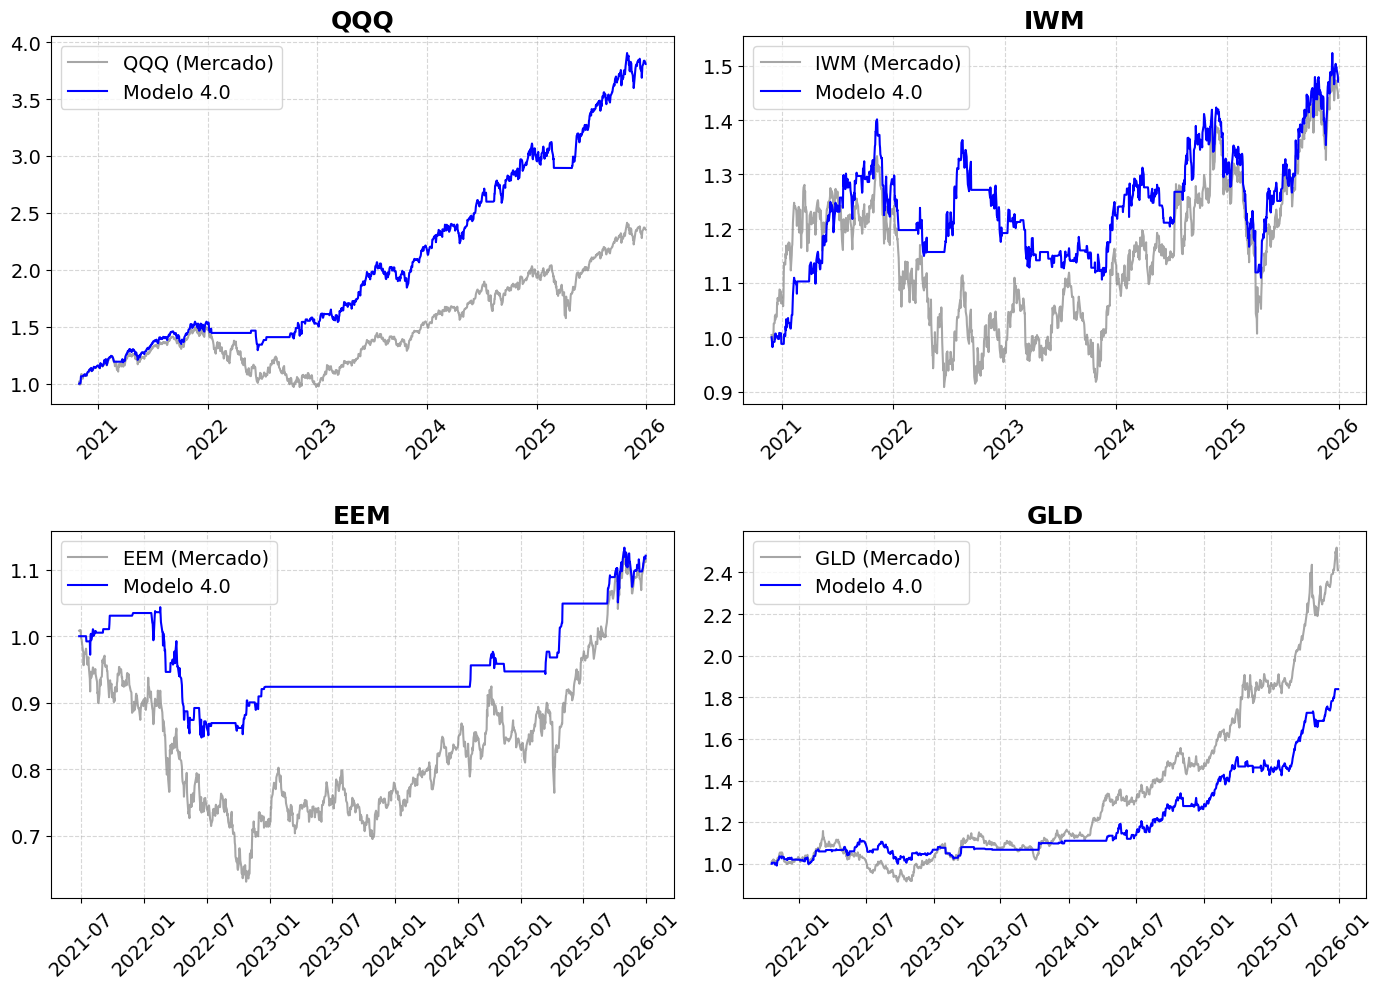


PROCESANDO TICKER: TLT (5/8)...
   -> Leyendo datos congelados de TLT desde el disco duro...
--- MÉTRICAS PARA TLT ---
Dentro de Muestra -> Prec. Dir.: 54.73% | RMSE: 0.672858
Fuera de Muestra  -> Prec. Dir.: 50.90% | RMSE: 0.700727
Mercado           -> Retorno:  -26.83% | Max DD:  -43.70% | Sharpe: -0.41
Estrategia        -> Retorno:    7.47% | Max DD:  -10.21% | Sharpe: 0.21

PROCESANDO TICKER: XLE (6/8)...
   -> Leyendo datos congelados de XLE desde el disco duro...
--- MÉTRICAS PARA XLE ---
Dentro de Muestra -> Prec. Dir.: 51.36% | RMSE: 0.697437
Fuera de Muestra  -> Prec. Dir.: 47.46% | RMSE: 0.724861
Mercado           -> Retorno:  297.25% | Max DD:  -26.04% | Sharpe: 0.95
Estrategia        -> Retorno:  123.28% | Max DD:   -9.96% | Sharpe: 1.38

PROCESANDO TICKER: EWW (7/8)...
   -> Leyendo datos congelados de EWW desde el disco duro...
--- MÉTRICAS PARA EWW ---
Dentro de Muestra -> Prec. Dir.: 57.72% | RMSE: 0.650267
Fuera de Muestra  -> Prec. Dir.: 50.54% | RMSE: 0.703283
Merca

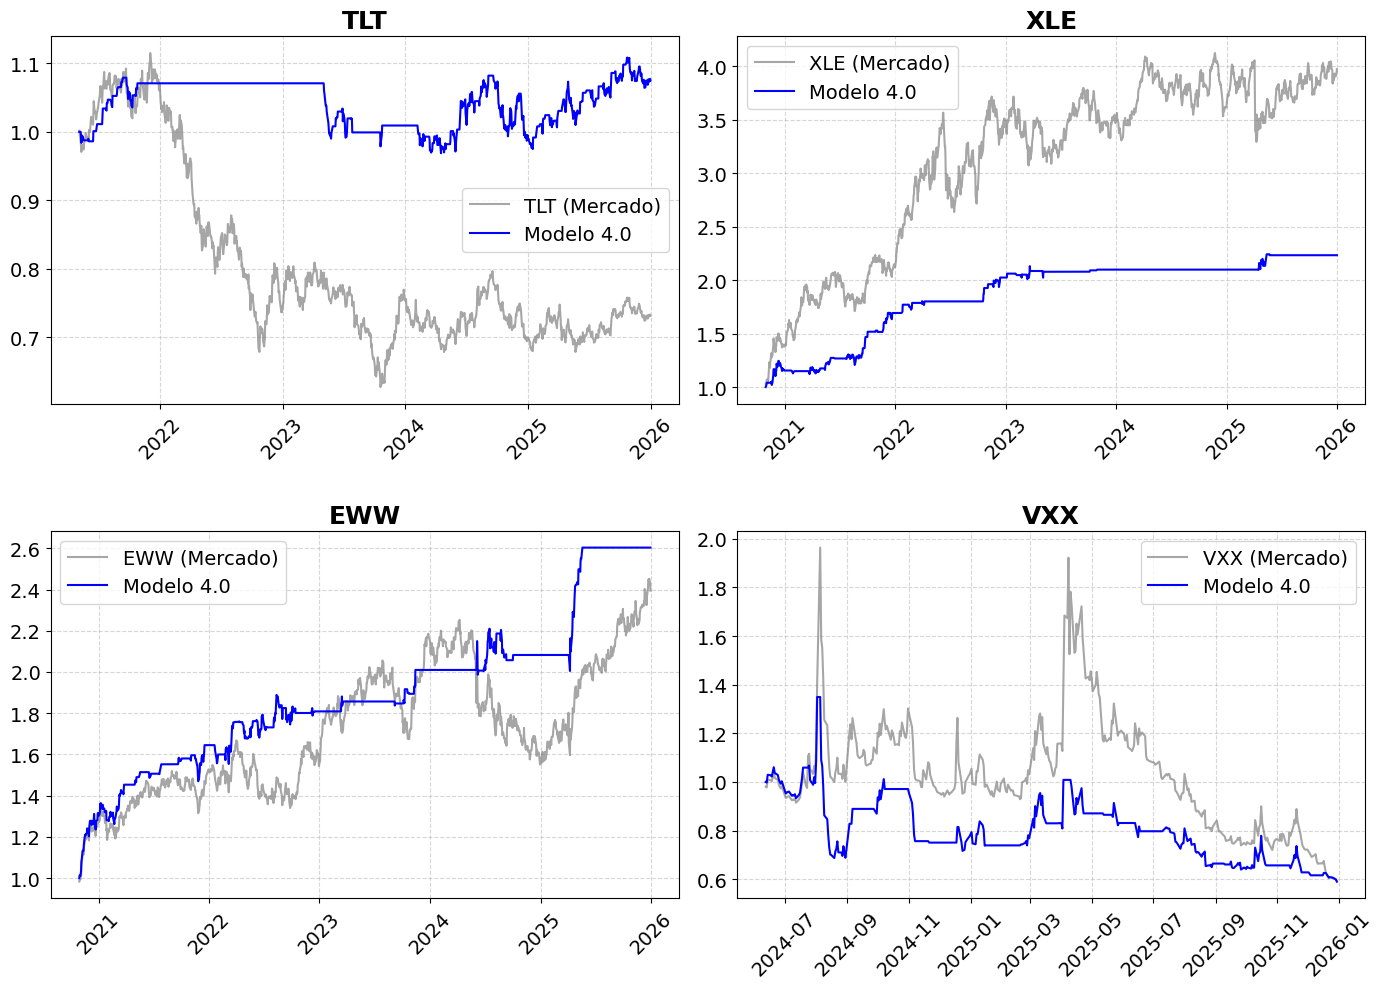

In [ ]:
# --- 1. CANDADOS DE DETERMINISMO ABSOLUTO ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

print(" BACKTEST DE PIPELINE JERÁRQUICO MULTI-ACTIVO")
tickers = ["QQQ", "IWM", "EEM", "GLD", "TLT", "XLE", "EWW", "VXX"]

num_tickers = len(tickers)

# --- NUEVA LÓGICA DE GRÁFICOS: Dos imágenes con 4 activos cada una ---
activos_por_imagen = 4
cols = 2
rows = 2

# Variables para manejar la figura actual
fig = None
axes = None
ax_idx = 0

for idx, ticker in enumerate(tickers):

    # Si estamos en el primer activo de un nuevo grupo de 4, creamos una nueva figura
    if idx % activos_por_imagen == 0:
        fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
        axes = axes.flatten()
        ax_idx = 0 # Reiniciamos el índice del eje para la nueva figura

    print(f"\n==================================================")
    print(f"PROCESANDO TICKER: {ticker} ({idx+1}/{num_tickers})...")
    print(f"==================================================")

    # --- INGENIERÍA DE DATOS CON TRUCO DE CONGELAMIENTO ---
    archivo_csv = f"datos_{ticker}_congelados.csv"

    if os.path.exists(archivo_csv):
        print(f"   -> Leyendo datos congelados de {ticker} desde el disco duro...")
        data = pd.read_csv(archivo_csv, index_col=0, parse_dates=True)
    else:
        print(f"   -> Descargando datos de {ticker} por ÚLTIMA VEZ...")
        data = yf.download(ticker, start="2000-01-01", end="2025-12-31", progress=False)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        data.to_csv(archivo_csv)

    price_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'
    data['Log_Return'] = np.log(data[price_col] / data[price_col].shift(1))
    data['Target_Dir'] = np.where(data['Log_Return'].shift(-1) > 0, 1, 0)

    data['SMA_15'] = data[price_col].rolling(window=15).mean()
    data['SMA_50'] = data[price_col].rolling(window=50).mean()
    data['Momentum_5D'] = data[price_col] / data[price_col].shift(5) - 1
    data['Roll_Vol_15'] = data['Log_Return'].rolling(window=15).std()
    data['Roll_Vol_30'] = data['Log_Return'].rolling(window=30).std()

    feature_cols = ['SMA_15', 'SMA_50', 'Momentum_5D', 'Roll_Vol_15', 'Roll_Vol_30']
    dataset = data[feature_cols + ['Log_Return', 'Target_Dir']].dropna()

    split_idx = int(len(dataset) * 0.8)
    train_data, test_data = dataset.iloc[:split_idx].copy(), dataset.iloc[split_idx:].copy()
    X_train, y_train_class = train_data[feature_cols], train_data['Target_Dir']
    X_test, y_test_class, y_test_returns = test_data[feature_cols], test_data['Target_Dir'], test_data['Log_Return']

    # --- ETAPA 1: IDENTIFICACIÓN DE REGÍMENES (GHMM) ---
    hmm_train_data = train_data['Log_Return'].values.reshape(-1, 1)
    model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
    model_hmm.fit(hmm_train_data)
    regimes_train = model_hmm.predict(hmm_train_data)
    regimes_test = model_hmm.predict(test_data['Log_Return'].values.reshape(-1, 1))

    # --- ETAPA 2: DIVISIÓN JERÁRQUICA Y ESCALADO ---
    X_train_R0, y_train_R0 = X_train[regimes_train == 0], y_train_class[regimes_train == 0]
    X_train_R1, y_train_R1 = X_train[regimes_train == 1], y_train_class[regimes_train == 1]

    scaler_R0 = StandardScaler().fit(X_train_R0)
    scaler_R1 = StandardScaler().fit(X_train_R1)

    # --- ETAPA 3: ENTRENAMIENTO DE SVC LOCALIZADO Y PENALIZADO ---
    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = {'C': [1, 10, 100], 'gamma': ['scale', 'auto', 0.01]}
    svc_base = SVC(class_weight='balanced', random_state=42)

    # n_jobs=1 para garantizar determinismo estricto
    grid_R0 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
    grid_R0.fit(scaler_R0.transform(X_train_R0), y_train_R0)
    best_svc_R0 = grid_R0.best_estimator_

    grid_R1 = GridSearchCV(svc_base, param_grid, cv=tscv, scoring='balanced_accuracy', n_jobs=1)
    grid_R1.fit(scaler_R1.transform(X_train_R1), y_train_R1)
    best_svc_R1 = grid_R1.best_estimator_

    # --- ENRUTAMIENTO DINÁMICO DENTRO DE MUESTRA (Para Métricas de Entrenamiento) ---
    y_pred_train_class = np.zeros(len(X_train))
    for i in range(len(X_train)):
        current_regime = regimes_train[i]
        current_features = X_train.iloc[i].values.reshape(1, -1)
        if current_regime == 0:
            y_pred_train_class[i] = best_svc_R0.predict(scaler_R0.transform(current_features))[0]
        else:
            y_pred_train_class[i] = best_svc_R1.predict(scaler_R1.transform(current_features))[0]

    # --- ENRUTAMIENTO DINÁMICO FUERA DE MUESTRA ---
    y_pred_class = np.zeros(len(X_test))
    for i in range(len(X_test)):
        current_regime = regimes_test[i]
        current_features = X_test.iloc[i].values.reshape(1, -1)
        if current_regime == 0:
            y_pred_class[i] = best_svc_R0.predict(scaler_R0.transform(current_features))[0]
        else:
            y_pred_class[i] = best_svc_R1.predict(scaler_R1.transform(current_features))[0]

    # --- BACKTESTING FINANCIERO Y CÁLCULO DE MÉTRICAS ---
    backtest_df = pd.DataFrame(index=y_test_class.index)
    backtest_df['Market_Returns'] = y_test_returns
    backtest_df['Signal'] = y_pred_class

    # El retorno de la estrategia usa la señal de AYER para el retorno de HOY (Lógica idéntica al 4.0)
    backtest_df['Strategy_Returns'] = backtest_df['Market_Returns'] * backtest_df['Signal'].shift(1)
    backtest_df.fillna(0, inplace=True)

    backtest_df['Cum_Market'] = np.exp(backtest_df['Market_Returns'].cumsum())
    backtest_df['Cum_Strategy'] = np.exp(backtest_df['Strategy_Returns'].cumsum())

    # Calcular Drawdowns, Retornos y Ratios de Sharpe
    total_mkt = (backtest_df['Cum_Market'].iloc[-1] - 1) * 100
    total_str = (backtest_df['Cum_Strategy'].iloc[-1] - 1) * 100
    max_dd_mkt = ((backtest_df['Cum_Market'] / backtest_df['Cum_Market'].cummax()) - 1).min() * 100
    max_dd_str = ((backtest_df['Cum_Strategy'] / backtest_df['Cum_Strategy'].cummax()) - 1).min() * 100
    sharpe_mkt = np.sqrt(252) * (backtest_df['Market_Returns'].mean() / backtest_df['Market_Returns'].std())
    sharpe_str = np.sqrt(252) * (backtest_df['Strategy_Returns'].mean() / backtest_df['Strategy_Returns'].std())

    # Calcular RMSE y Precisión Direccional
    train_acc = accuracy_score(y_train_class, y_pred_train_class)
    train_rmse = np.sqrt(mean_squared_error(y_train_class, y_pred_train_class))
    test_acc = accuracy_score(y_test_class, y_pred_class)
    test_rmse = np.sqrt(mean_squared_error(y_test_class, y_pred_class))

    # Imprimir Resultados Formateados para el Ticker Actual
    print(f"--- MÉTRICAS PARA {ticker} ---")
    print(f"Dentro de Muestra -> Prec. Dir.: {train_acc*100:.2f}% | RMSE: {train_rmse:.6f}")
    print(f"Fuera de Muestra  -> Prec. Dir.: {test_acc*100:.2f}% | RMSE: {test_rmse:.6f}")
    print(f"Mercado           -> Retorno: {total_mkt:>7.2f}% | Max DD: {max_dd_mkt:>7.2f}% | Sharpe: {sharpe_mkt:.2f}")
    print(f"Estrategia        -> Retorno: {total_str:>7.2f}% | Max DD: {max_dd_str:>7.2f}% | Sharpe: {sharpe_str:.2f}")

# --- GRAFICAR EN LA CUADRÍCULA ---
    ax = axes[ax_idx]
    ax.plot(backtest_df.index, backtest_df['Cum_Market'], label=f'{ticker} (Mercado)', color='gray', alpha=0.7)
    ax.plot(backtest_df.index, backtest_df['Cum_Strategy'], label='Modelo 4.0', color='blue', linewidth=1.5)

    # 1. Título del activo más grande (16 para que resalte)
    ax.set_title(f'{ticker}', fontsize=18, fontweight='bold')

    # 2. Leyenda más grande (12 es el tamaño ideal para subgráficos sin tapar la línea)
    ax.legend(fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)

    # 3. Hacer los números de AMBOS ejes más grandes (14) y mantener la rotación
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

    ax_idx += 1 # Avanzamos al siguiente cuadrante

    # --- CONDICIÓN DE CORTE PARA MOSTRAR LA IMAGEN ---
    # Si hemos llenado los 4 espacios (o es el último ticker de la lista), mostramos la figura
    if (idx + 1) % activos_por_imagen == 0 or (idx + 1) == num_tickers:

        # Limpiar cualquier subgráfico vacío si la última imagen no tiene 4 activos
        if (idx + 1) == num_tickers and (idx + 1) % activos_por_imagen != 0:
             for j in range(ax_idx, len(axes)):
                 fig.delaxes(axes[j])

        plt.tight_layout(h_pad=3.0)
        plt.show()

# --- FIN DEL BUCLE FOR ---